# Drug Stock Forecasting

Layer 1 learns a global XGBoost model that predicts closing_stock one month ahead for every facility-drug combination in the district. The model is trained on 24 months of synthetic transactional history covering ten puskesmas and thirty maternal drugs. A rich feature set combines stock lags at one, two, three, six, and twelve months, a rolling mean and standard deviation bank, lagged case and consumption signals, cyclic calendar encodings, and interaction terms that capture how accessibility and disease burden jointly shape demand. The target is log1p-transformed to stabilize variance across the wide range of stock levels observed in the district.

## Environment Setup

In [1]:
!pip install xgboost scikit-learn matplotlib seaborn pandas numpy joblib --quiet


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import os, json, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR   = '/content/drive/MyDrive/ai-asean'
DATA_PATH  = f'{BASE_DIR}/maternal_dataset_filled.csv'
MODEL_DIR  = f'{BASE_DIR}/model_v3'
FIGURE_DIR = f'{BASE_DIR}/figures_v3'

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = sns.color_palette('muted')

print('Directories ready.')
print(f'  Model   -> {MODEL_DIR}')
print(f'  Figures -> {FIGURE_DIR}')


Directories ready.
  Model   -> /content/drive/MyDrive/ai-asean/model_v3
  Figures -> /content/drive/MyDrive/ai-asean/figures_v3


## Load and Inspect Data

The input table is the monthly transactional panel produced by the data simulator. Each row represents one facility-drug-period observation and carries the closing stock, estimated total cases, lead time, accessibility category, and the static dosing parameters. The period column is parsed as a datetime index so lag and rolling operations can be applied correctly within each facility-drug group.

In [4]:
df = pd.read_csv(DATA_PATH)
df['period'] = pd.to_datetime(df['period'])
df = df.sort_values(['facility_id', 'drug_id', 'period']).reset_index(drop=True)

print('Shape           :', df.shape)
print('Period range    :', df['period'].min().date(), '->', df['period'].max().date())
print('Facilities      :', df['facility_id'].nunique())
print('Drugs           :', df['drug_id'].nunique())
print('Nulls per column:')
print(df.isnull().sum())
print()
df.head()


Shape           : (7200, 12)
Period range    : 2023-03-01 -> 2025-02-01
Facilities      : 10
Drugs           : 30
Nulls per column:
facility_id                0
drug_id                    0
period                     0
closing_stock              0
estimated_total_cases      0
lead_time_days             0
rainy_season_access        0
accessibility_score        0
standard_daily_dose        0
treatment_duration_days    0
month                      0
year                       0
dtype: int64



,facility_id,drug_id,period,closing_stock,estimated_total_cases,lead_time_days,rainy_season_access,accessibility_score,standard_daily_dose,treatment_duration_days,month,year
0,PKM-001,OBT-001,2023-03-01,1143,1008,14.0,terputus,1,6,7,3,2023
1,PKM-001,OBT-001,2023-04-01,309,811,14.0,terputus,1,6,7,4,2023
2,PKM-001,OBT-001,2023-05-01,815,797,14.0,terputus,1,6,7,5,2023
3,PKM-001,OBT-001,2023-06-01,356,987,14.0,terputus,1,6,7,6,2023
4,PKM-001,OBT-001,2023-07-01,432,1016,14.0,terputus,1,6,7,7,2023


## Exploratory Data Analysis

Before engineering features the distributional properties of closing stock and its relationship to the key covariates are inspected visually. The goals are to confirm that the November demand surge appears in the data, that remote facilities have systematically lower stock levels, and that no unexpected structural breaks or data artifacts are present.

### Closing Stock Distribution

The marginal distribution of closing stock across all facility-drug-period observations reveals the scale and skew of the forecasting target. Heavy right tails motivate the log1p transformation applied before training.

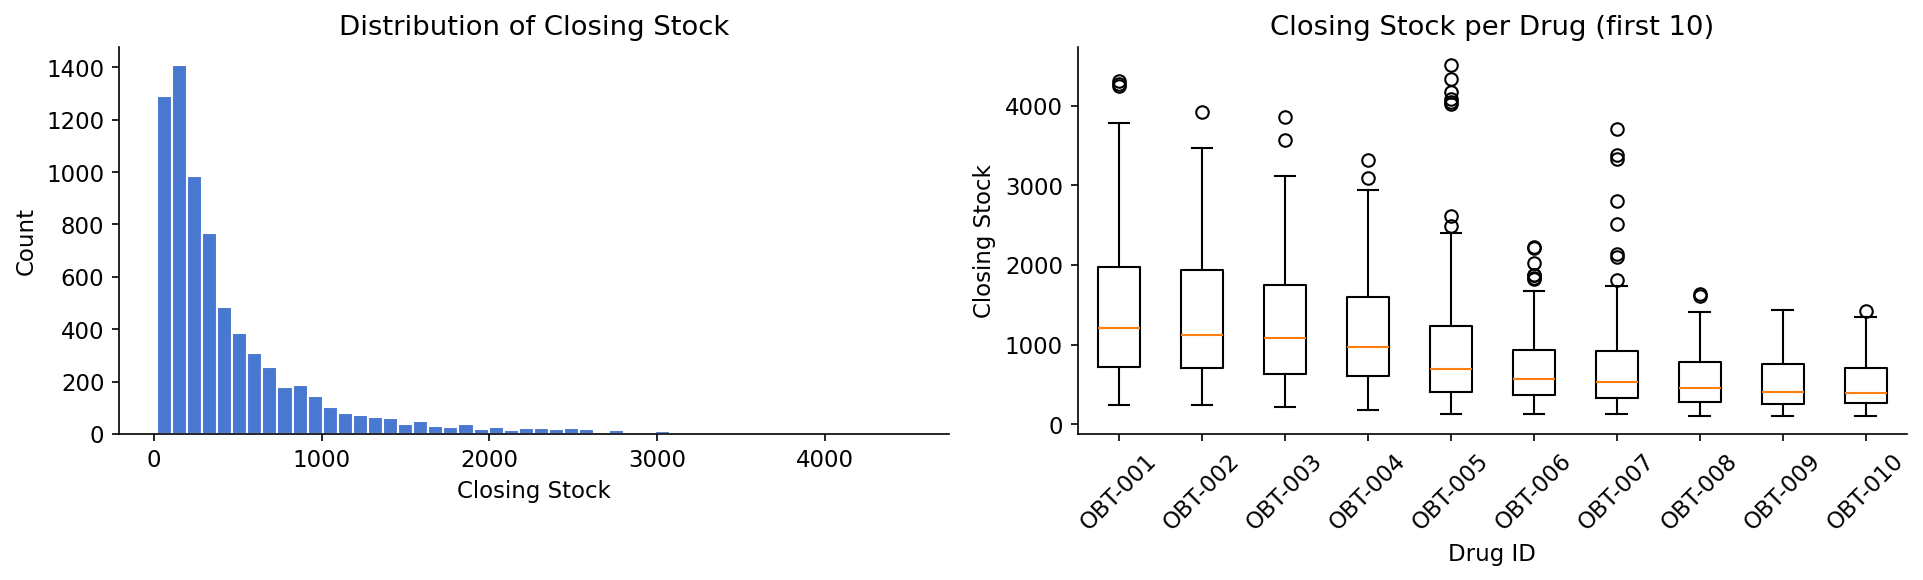

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['closing_stock'], bins=50, color=PALETTE[0], edgecolor='white')
axes[0].set_title('Distribution of Closing Stock')
axes[0].set_xlabel('Closing Stock')
axes[0].set_ylabel('Count')

sample_drugs = sorted(df['drug_id'].unique())[:10]
data_box = [df[df['drug_id'] == d]['closing_stock'].values for d in sample_drugs]
axes[1].boxplot(data_box, labels=sample_drugs, vert=True)
axes[1].set_title('Closing Stock per Drug (first 10)')
axes[1].set_xlabel('Drug ID')
axes[1].set_ylabel('Closing Stock')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/01_closing_stock_distribution.png', bbox_inches='tight')
plt.show()


### Monthly Aggregate Trend

The district-wide monthly mean and median closing stock trace the seasonal rhythm of the supply chain. A visible dip in mid-year months and a spike in the October through December window confirm that the simulator has correctly encoded the high-demand season.

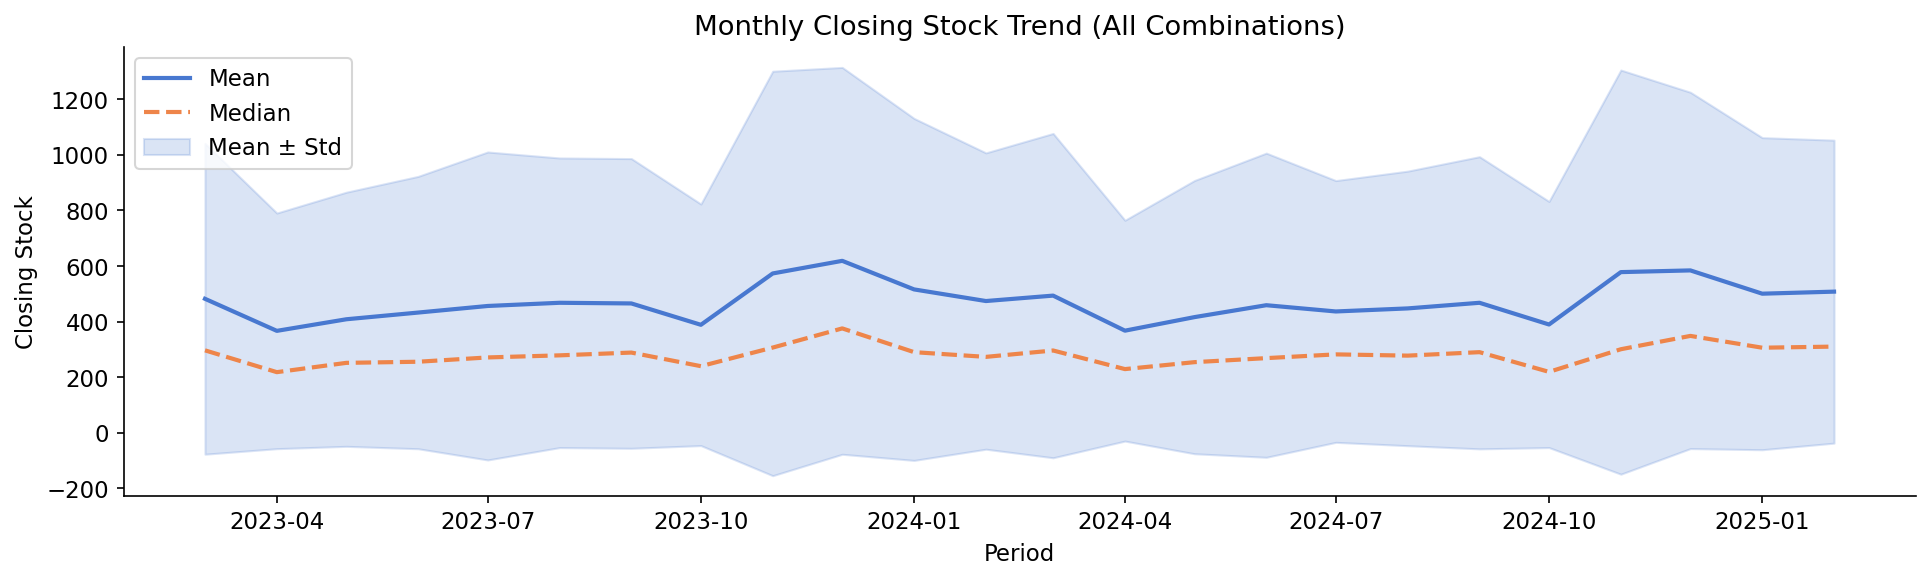

In [6]:
monthly = df.groupby('period')['closing_stock'].agg(['mean','median','std']).reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly['period'], monthly['mean'],   label='Mean',   color=PALETTE[0], linewidth=2)
ax.plot(monthly['period'], monthly['median'], label='Median', color=PALETTE[1], linewidth=2, linestyle='--')
ax.fill_between(monthly['period'],
                monthly['mean'] - monthly['std'],
                monthly['mean'] + monthly['std'],
                alpha=0.2, color=PALETTE[0], label='Mean ± Std')
ax.set_title('Monthly Closing Stock Trend (All Combinations)')
ax.set_xlabel('Period'); ax.set_ylabel('Closing Stock'); ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/02_monthly_trend.png', bbox_inches='tight')
plt.show()


### Trend by Facility

Facility-level trajectories show how access category and remoteness produce divergent stock profiles. Facilities with disrupted rainy season access exhibit the sharpest troughs, which the model must learn to anticipate from the static exogenous features.

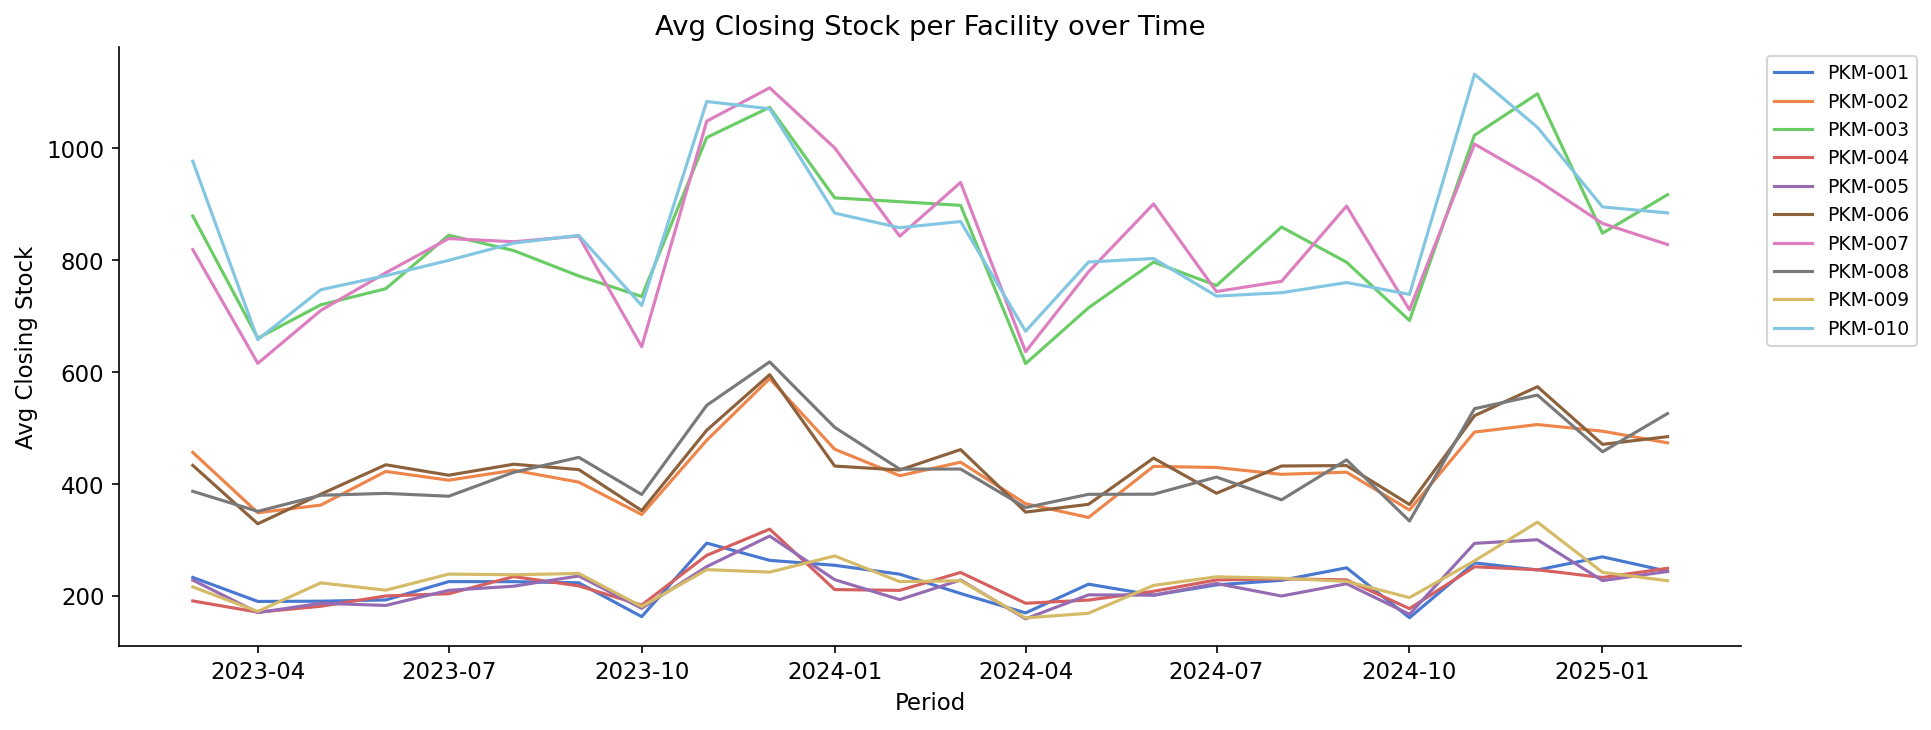

In [7]:
fac_monthly = df.groupby(['period','facility_id'])['closing_stock'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
for i, fid in enumerate(sorted(df['facility_id'].unique())):
    sub = fac_monthly[fac_monthly['facility_id'] == fid]
    ax.plot(sub['period'], sub['closing_stock'], label=fid,
            color=PALETTE[i % len(PALETTE)], linewidth=1.5)
ax.set_title('Avg Closing Stock per Facility over Time')
ax.set_xlabel('Period'); ax.set_ylabel('Avg Closing Stock')
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/03_trend_by_facility.png', bbox_inches='tight')
plt.show()


### Closing Stock by Rainy Season Access

A grouped summary of closing stock by rainy season access category quantifies the structural disadvantage faced by remote facilities. The gap between normal and disrupted access motivates including rainy_season_enc as a feature and tracking facility-level metrics in the evaluation.

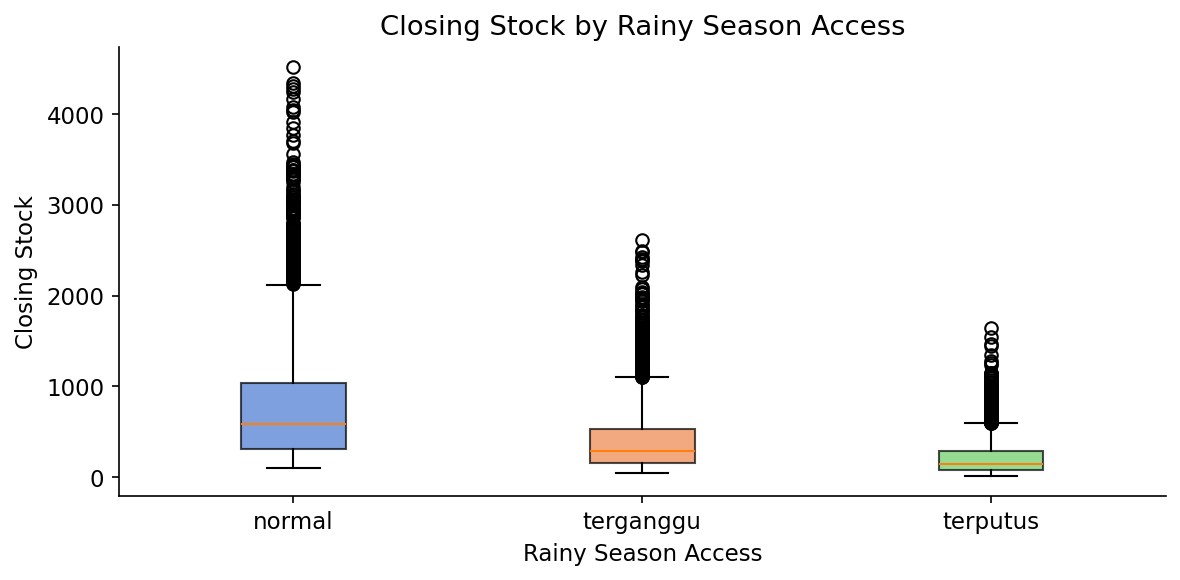

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
order = ['normal', 'terganggu', 'terputus']
data_rain = [df[df['rainy_season_access'] == o]['closing_stock'].values for o in order]
bp = ax.boxplot(data_rain, labels=order, patch_artist=True)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title('Closing Stock by Rainy Season Access')
ax.set_xlabel('Rainy Season Access'); ax.set_ylabel('Closing Stock')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/04_stock_by_rainy.png', bbox_inches='tight')
plt.show()


### Correlation Heatmap

Pairwise Pearson correlations among the numeric columns confirm that closing stock is most strongly associated with its own lags and with estimated total cases, validating the lag bank design. Lead time and accessibility show weaker but directionally consistent negative associations with stock levels.

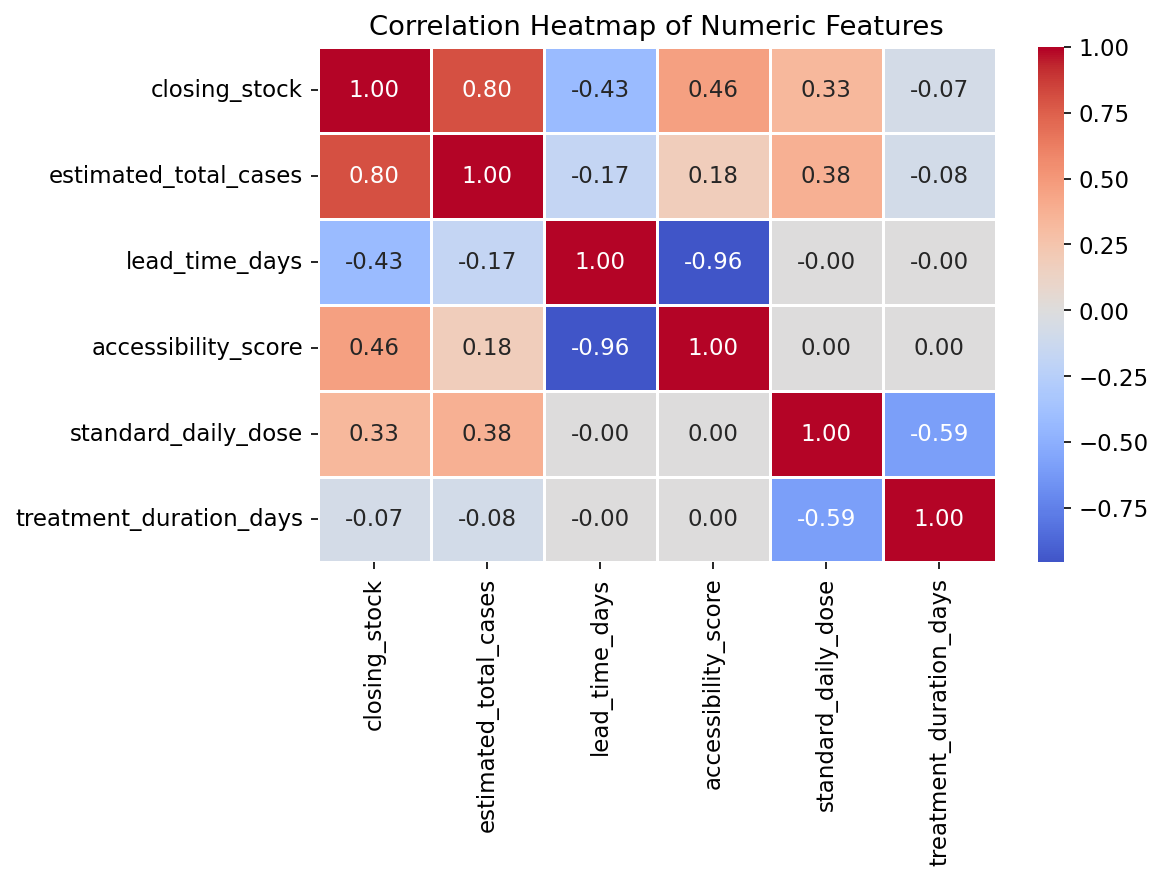

In [9]:
num_cols = ['closing_stock','estimated_total_cases','lead_time_days',
            'accessibility_score','standard_daily_dose','treatment_duration_days']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/05_correlation_heatmap.png', bbox_inches='tight')
plt.show()


### November Seasonality Spike

Monthly aggregates of estimated total cases confirm the November incidence surge that the simulator encodes. The is_november and is_high_season binary flags, together with the cyclic month encodings, are designed to give the model an explicit handle on this pattern.

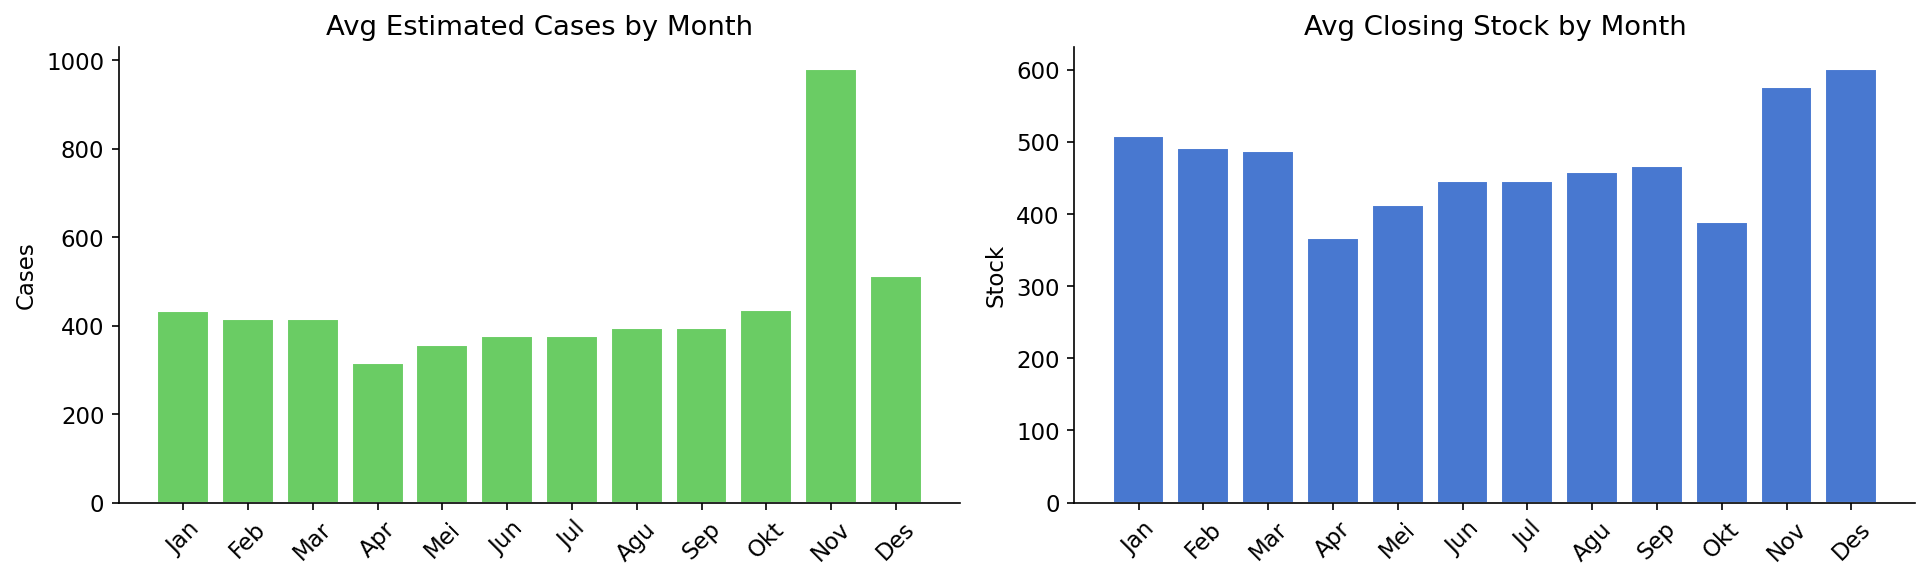

Nov spike visible — confirms seasonal feature importance.


In [10]:
# Confirm the Nov demand surge in estimated_total_cases
monthly_cases = df.groupby(df['period'].dt.month)['estimated_total_cases'].mean()
monthly_stock = df.groupby(df['period'].dt.month)['closing_stock'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
month_labels = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

axes[0].bar(range(1,13), monthly_cases.values, color=PALETTE[2], edgecolor='white')
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(month_labels, rotation=45)
axes[0].set_title('Avg Estimated Cases by Month')
axes[0].set_ylabel('Cases')

axes[1].bar(range(1,13), monthly_stock.values, color=PALETTE[0], edgecolor='white')
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(month_labels, rotation=45)
axes[1].set_title('Avg Closing Stock by Month')
axes[1].set_ylabel('Stock')

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/06_seasonality.png', bbox_inches='tight')
plt.show()
print('Nov spike visible — confirms seasonal feature importance.')


### Sample Time Series

Four representative facility-drug combinations illustrate the variety of temporal patterns in the panel: stable high-stock combinations at well-connected facilities, volatile low-stock series at remote ones, and combinations whose demand tracks the seasonal case count closely. The model must generalize across all of these regimes.

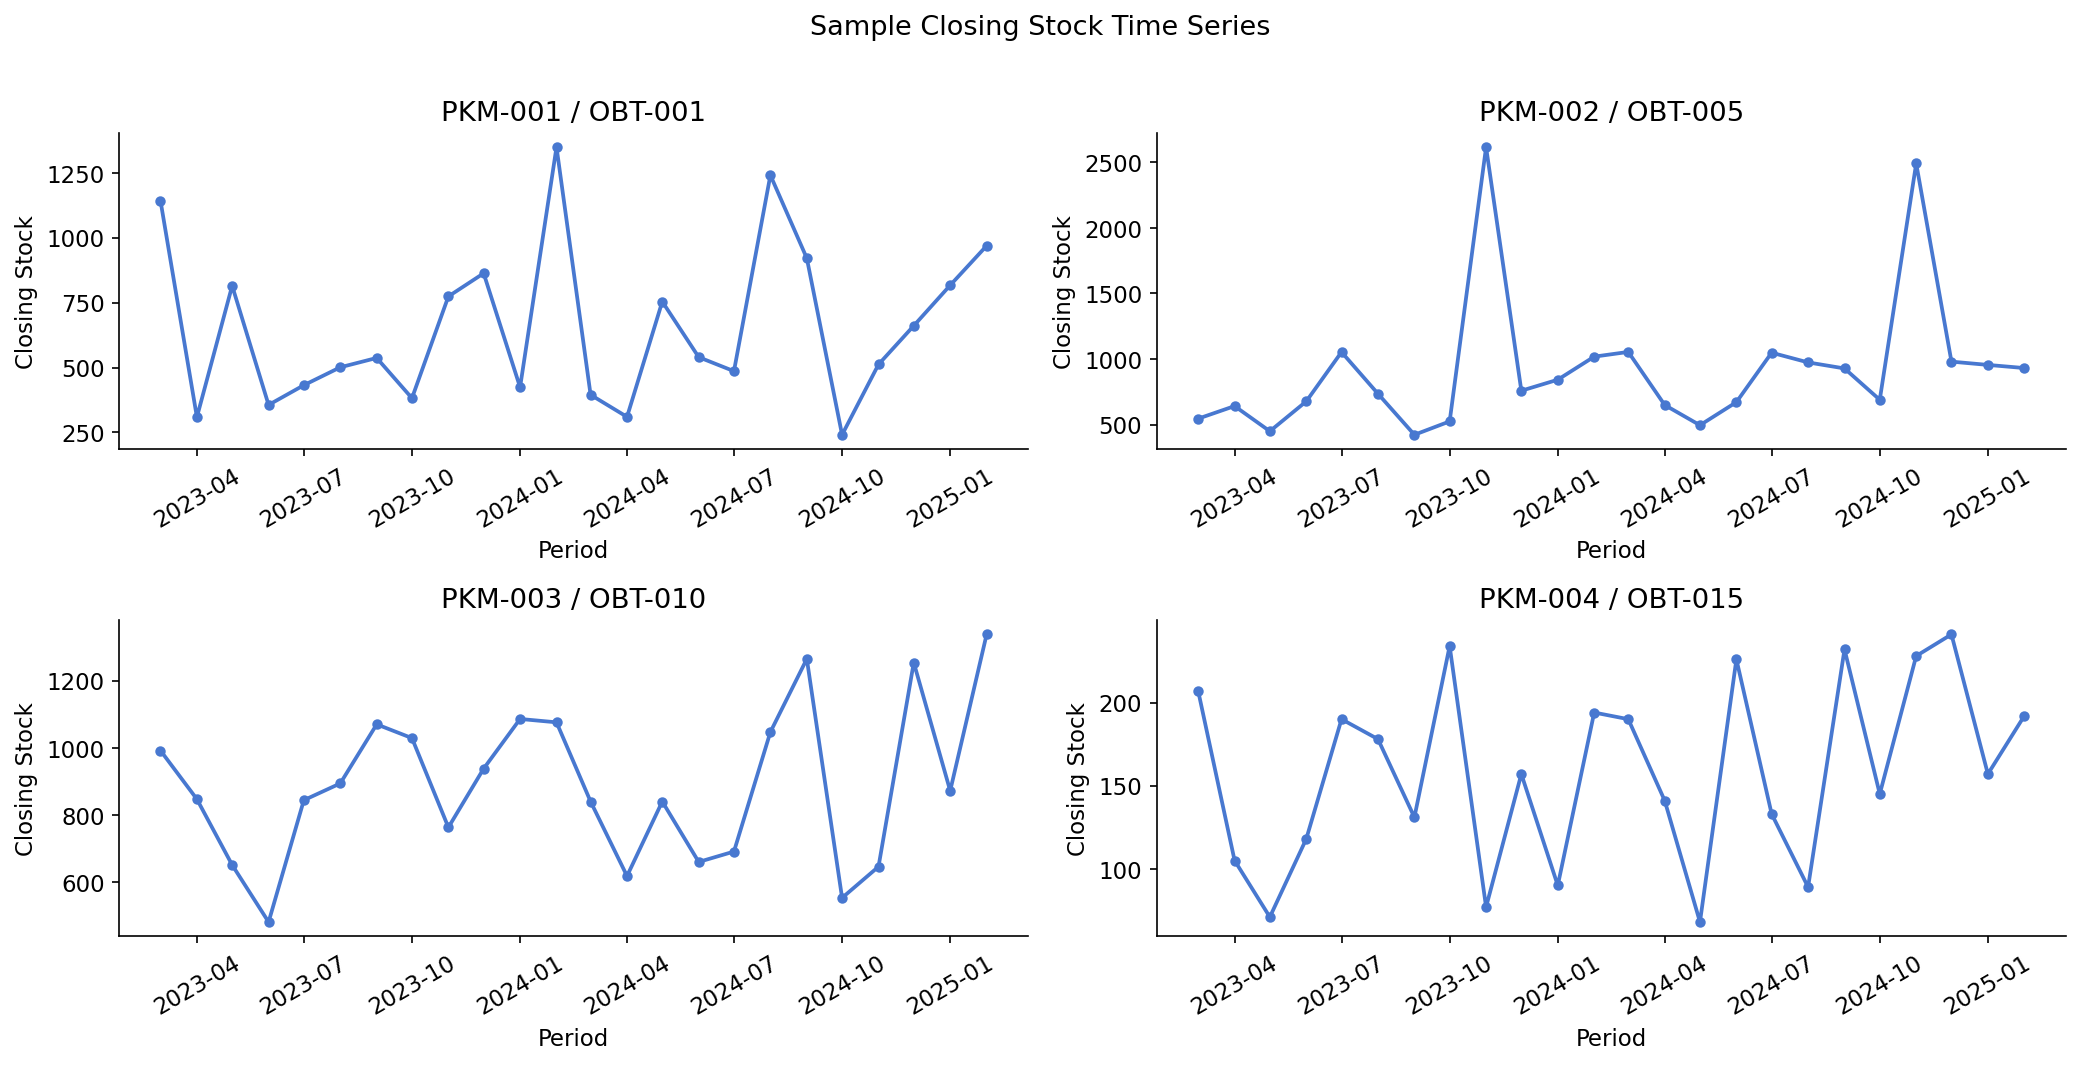

In [11]:
samples = [('PKM-001','OBT-001'), ('PKM-002','OBT-005'),
           ('PKM-003','OBT-010'), ('PKM-004','OBT-015')]

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=False)
for ax, (fid, did) in zip(axes.flatten(), samples):
    sub = df[(df['facility_id']==fid) & (df['drug_id']==did)].sort_values('period')
    ax.plot(sub['period'], sub['closing_stock'], marker='o', markersize=4,
            color=PALETTE[0], linewidth=1.8)
    ax.set_title(f'{fid} / {did}')
    ax.set_xlabel('Period'); ax.set_ylabel('Closing Stock')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Sample Closing Stock Time Series', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/07_sample_time_series.png', bbox_inches='tight')
plt.show()


## Feature Engineering

The feature set is designed around two complementary ideas. First, a rich lag bank at one, two, three, six, and twelve months of closing stock, together with three-month lags of estimated total cases and derived consumption, gives the model direct access to the autoregressive structure of each series. Second, rolling statistics, cyclic calendar encodings, and interaction terms between cases, accessibility, and lead time embed the epidemiological and logistical context that explains cross-facility variation. The target is log1p-transformed before training to compress the right tail and stabilize gradient updates across stock levels that span two orders of magnitude.

### Encode Categoricals

Facility identifiers, drug identifiers, and the rainy season access category are integer-encoded with scikit-learn LabelEncoder instances that are saved alongside the model for use during inference. The encoders are fitted on the full panel so every valid category has a known code at serving time.

In [12]:
le_facility = LabelEncoder()
le_drug     = LabelEncoder()
le_rainy    = LabelEncoder()

df['facility_enc']     = le_facility.fit_transform(df['facility_id'])
df['drug_enc']         = le_drug.fit_transform(df['drug_id'])
df['rainy_season_enc'] = le_rainy.fit_transform(df['rainy_season_access'])

joblib.dump(le_facility, f'{MODEL_DIR}/le_facility.pkl')
joblib.dump(le_drug,     f'{MODEL_DIR}/le_drug.pkl')
joblib.dump(le_rainy,    f'{MODEL_DIR}/le_rainy.pkl')
print('Encoders saved.')
print('Rainy classes:', list(le_rainy.classes_))


Encoders saved.
Rainy classes: ['normal', 'terganggu', 'terputus']


### Static Exog Lookup

For each facility-drug combination the time-invariant attributes, facility encoding, drug encoding, lead time, rainy season encoding, accessibility score, standard daily dose, and treatment duration, are captured once in a lookup table. At inference time this table eliminates the need to supply these fields explicitly for known combinations, and the saved CSV is loaded by the serving layer as a side artifact.

In [13]:
exog_cols = ['facility_enc','drug_enc','lead_time_days','rainy_season_enc',
             'accessibility_score','standard_daily_dose','treatment_duration_days']

static_lookup = (
    df.groupby(['facility_id','drug_id'])[exog_cols]
    .first()
    .reset_index()
)

static_lookup.to_csv(f'{MODEL_DIR}/static_exog_lookup.csv', index=False)
print('Static lookup saved. Shape:', static_lookup.shape)
static_lookup.head()


Static lookup saved. Shape: (300, 9)


,facility_id,drug_id,facility_enc,drug_enc,lead_time_days,rainy_season_enc,accessibility_score,standard_daily_dose,treatment_duration_days
0,PKM-001,OBT-001,0,0,14.0,2,1,6,7
1,PKM-001,OBT-002,0,1,14.0,2,1,3,7
2,PKM-001,OBT-003,0,2,14.0,2,1,4,3
3,PKM-001,OBT-004,0,3,14.0,2,1,2,30
4,PKM-001,OBT-005,0,4,14.0,2,1,1,30


### Build All Features

The build_features function applies all lag, rolling, calendar, and interaction transformations in a single pass over the sorted panel. Lags are computed within each facility-drug group using groupby shift operations so no information leaks across combinations. Rolling statistics are derived from the already-shifted lag-one series to maintain strict temporal ordering.

In [ ]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(['facility_id', 'drug_id', 'period']).copy()

    df['estimated_consumption'] = (
        df['estimated_total_cases'] *
        df['standard_daily_dose'] *
        df['treatment_duration_days']
    )

    grp_stk  = df.groupby(['facility_id','drug_id'])['closing_stock']
    grp_cas  = df.groupby(['facility_id','drug_id'])['estimated_total_cases']
    grp_cons = df.groupby(['facility_id','drug_id'])['estimated_consumption']

    for lag in [1, 2, 3, 6, 12]:
        df[f'lag_{lag}'] = grp_stk.shift(lag)


    for lag in [1, 2, 3]:
        df[f'cases_lag_{lag}'] = grp_cas.shift(lag)

    for lag in [1, 2, 3]:
        df[f'cons_lag_{lag}'] = grp_cons.shift(lag)

    shifted = grp_stk.shift(1)
    for w in [3, 6, 12]:
        df[f'roll_mean_{w}'] = shifted.transform(
            lambda x: x.rolling(w, min_periods=1).mean())
        df[f'roll_std_{w}']  = shifted.transform(
            lambda x: x.rolling(w, min_periods=1).std().fillna(0))

    df['month']     = df['period'].dt.month
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['year']      = df['period'].dt.year
    df['quarter']   = df['period'].dt.quarter

    df['is_november']    = (df['month'] == 11).astype(int)
    df['is_high_season'] = df['month'].isin([10, 11, 12]).astype(int)
    df['is_low_season']  = (df['month'] == 4).astype(int)

    df['cases_x_access']    = df['estimated_total_cases'] * df['accessibility_score']
    df['lead_x_access']     = df['lead_time_days'] * df['accessibility_score']
    df['nov_x_cases']       = df['is_november'] * df['estimated_total_cases']
    df['dose_x_duration']   = df['standard_daily_dose'] * df['treatment_duration_days']
    df['lag1_x_access']     = df['lag_1'] * df['accessibility_score']
    return df

df = build_features(df)

LAG_FEATURES      = [f'lag_{l}' for l in [1,2,3,6,12]]
CASES_LAG_FEATURES= [f'cases_lag_{l}' for l in [1,2,3]]
CONS_LAG_FEATURES = [f'cons_lag_{l}' for l in [1,2,3]]
ROLLING_FEATURES  = [f'roll_mean_{w}' for w in [3,6,12]] + [f'roll_std_{w}' for w in [3,6,12]]
EXOG_FEATURES     = ['facility_enc','drug_enc','lead_time_days','rainy_season_enc',
                     'accessibility_score','standard_daily_dose','treatment_duration_days']
CALENDAR_FEATURES = ['month','month_sin','month_cos','year','quarter',
                     'is_november','is_high_season','is_low_season']
INTERACTION_FEATURES = ['cases_x_access','lead_x_access','nov_x_cases',
                        'dose_x_duration','lag1_x_access']

FEATURE_COLS = (LAG_FEATURES + CASES_LAG_FEATURES + CONS_LAG_FEATURES +
                ROLLING_FEATURES + EXOG_FEATURES + CALENDAR_FEATURES +
                INTERACTION_FEATURES)

TARGET_COL   = 'closing_stock'

print(f'Total features: {len(FEATURE_COLS)}')
for f in FEATURE_COLS:
    print(' ', f)


Total features: 37
  lag_1
  lag_2
  lag_3
  lag_6
  lag_12
  cases_lag_1
  cases_lag_2
  cases_lag_3
  cons_lag_1
  cons_lag_2
  cons_lag_3
  roll_mean_3
  roll_mean_6
  roll_mean_12
  roll_std_3
  roll_std_6
  roll_std_12
  facility_enc
  drug_enc
  lead_time_days
  rainy_season_enc
  accessibility_score
  standard_daily_dose
  treatment_duration_days
  month
  month_sin
  month_cos
  year
  quarter
  is_november
  is_high_season
  is_low_season
  cases_x_access
  lead_x_access
  nov_x_cases
  dose_x_duration
  lag1_x_access


### Prepare Modeling DataFrame

Rows where lag_1 is missing are dropped, which removes only the first observation in each facility-drug series. All other missing lags, which arise when a series is shorter than the lag window, are filled with the per-combination median so every remaining row can be passed to the model without imputation at inference time.

In [15]:
# Drop only where lag_1 is NaN (first row per combo) — minimal data loss
df_model = df.dropna(subset=['lag_1', 'lag_2', 'lag_3']).copy()

# Fill remaining NaN lags with per-combo rolling median
fill_cols = ['lag_6','lag_12'] + CASES_LAG_FEATURES + CONS_LAG_FEATURES
for col in fill_cols:
    df_model[col] = df_model.groupby(['facility_id','drug_id'])[col].transform(
        lambda x: x.fillna(x.expanding().median())
    )

# Also fill lag1_x_access after lags are filled
df_model['lag1_x_access'] = df_model['lag_1'] * df_model['accessibility_score']

# Log1p-transform target
df_model['target_log'] = np.log1p(df_model[TARGET_COL])

print('Rows in model df:', len(df_model))
print('Remaining nulls in features:')
print(df_model[FEATURE_COLS].isnull().sum()[df_model[FEATURE_COLS].isnull().sum() > 0])


Rows in model df: 6300
Remaining nulls in features:
lag_6      900
lag_12    2700
dtype: int64


## Train and Validation Split

The last three calendar months of the panel, December 2024, January 2025, and February 2025, are held out as the validation set. This cutoff ensures that the November 2024 incidence spike is fully visible during training, which is essential for the model to learn the seasonal pattern rather than treat it as an outlier. The temporal split also mirrors the production setting where the model is always evaluated on the most recent unseen months.

In [16]:
CUTOFF = pd.Timestamp('2024-11-01')

train_df = df_model[df_model['period'] <= CUTOFF]
val_df   = df_model[df_model['period'] >  CUTOFF]

X_train  = train_df[FEATURE_COLS]
y_train  = train_df['target_log']       # train on log scale
X_val    = val_df[FEATURE_COLS]
y_val    = val_df[TARGET_COL]           # evaluate on original scale

print(f'Train: {len(X_train):,} rows | {train_df["period"].min().date()} → {train_df["period"].max().date()}')
print(f'Val  : {len(X_val):,} rows  | {val_df["period"].min().date()} → {val_df["period"].max().date()}')
print(f'Train months seen: {sorted(train_df["period"].dt.month.unique())}')


Train: 5,400 rows | 2023-06-01 → 2024-11-01
Val  : 900 rows  | 2024-12-01 → 2025-02-01
Train months seen: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


## Model Training

XGBoost is trained with 1500 estimators at a learning rate of 0.02, a maximum tree depth of six, and a minimum child weight of five. Gradient-based subsampling at 85 percent of rows and columns per tree regularises the model against the many low-frequency facility-drug combinations. Early stopping on log-scale RMSE with a patience of 50 rounds prevents overfitting. The GPU device is used when available; removing the device argument falls back to the CPU trainer without any other change.

In [17]:
model = XGBRegressor(
    n_estimators       = 1500,
    learning_rate      = 0.02,
    max_depth          = 6,
    subsample          = 0.85,
    colsample_bytree   = 0.85,
    colsample_bylevel  = 0.9,
    min_child_weight   = 5,
    reg_alpha          = 0.1,
    reg_lambda         = 1.5,
    gamma              = 0.05,
    tree_method        = 'hist',
    device             = 'cuda',   # change to 'cpu' if no GPU
    random_state       = 42,
    eval_metric        = 'rmse',
    early_stopping_rounds = 100,
    verbosity          = 1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, np.log1p(val_df[TARGET_COL]))],
    verbose=100
)

model.save_model(f'{MODEL_DIR}/xgboost_drug_forecast_v3.json')
joblib.dump(FEATURE_COLS, f'{MODEL_DIR}/feature_cols.pkl')
print('Model and feature list saved.')
print(f'Best iteration: {model.best_iteration}')


[0]	validation_0-rmse:0.99626
[100]	validation_0-rmse:0.34799
[200]	validation_0-rmse:0.31487
[300]	validation_0-rmse:0.31431
[371]	validation_0-rmse:0.31488
Model and feature list saved.
Best iteration: 271


## Evaluation

Model performance is assessed on the held-out validation set using MAE, MAPE, SMAPE, RMSE, and R-squared. The primary targets are an MAE below 100 units and a MAPE below 20 percent, which reflect the practical tolerance for procurement planning errors in the district setting. Results are broken down by facility and drug to identify which combinations drive the aggregate error.

In [18]:
y_pred_log = model.predict(X_val)
y_pred_val = np.clip(np.expm1(y_pred_log), 0, None)

mae   = mean_absolute_error(y_val, y_pred_val)
rmse  = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2    = r2_score(y_val, y_pred_val)

# MAPE — standard (actuals all > 0 after our fill)
mape  = np.mean(np.abs((y_val.values - y_pred_val) / (y_val.values + 1e-9))) * 100

# SMAPE — symmetric, robust complement
smape = np.mean(2 * np.abs(y_val.values - y_pred_val) /
                (np.abs(y_val.values) + np.abs(y_pred_val) + 1e-9)) * 100

print('=' * 45)
print('  Validation Metrics (original scale)')
print('=' * 45)
print(f'  MAE   : {mae:.2f}    (target < 100)')
print(f'  RMSE  : {rmse:.2f}')
print(f'  MAPE  : {mape:.2f}%  (target < 20%)')
print(f'  SMAPE : {smape:.2f}%')
print(f'  R²    : {r2:.4f}')
print('=' * 45)

if mae < 100 and mape < 20:
    print('✅ Both targets achieved!')
else:
    if mae >= 100:
        print(f'⚠️  MAE {mae:.1f} above target (100) — consider more lag features or re-tuning')
    if mape >= 20:
        print(f'⚠️  MAPE {mape:.1f}% above target (20%) — check low-stock combos')

metrics = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'SMAPE': smape, 'R2': r2}
with open(f'{MODEL_DIR}/validation_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Metrics saved.')


  Validation Metrics (original scale)
  MAE   : 108.97    (target < 100)
  RMSE  : 178.20
  MAPE  : 26.46%  (target < 20%)
  SMAPE : 25.50%
  R²    : 0.9071
⚠️  MAE 109.0 above target (100) — consider more lag features or re-tuning
⚠️  MAPE 26.5% above target (20%) — check low-stock combos
Metrics saved.


### Actual vs Predicted

Scatter and residual plots visualize the overall calibration of the model across the full range of stock levels. Systematic curvature or heteroscedasticity in the residuals would indicate that the log transformation is insufficient or that additional features are needed.

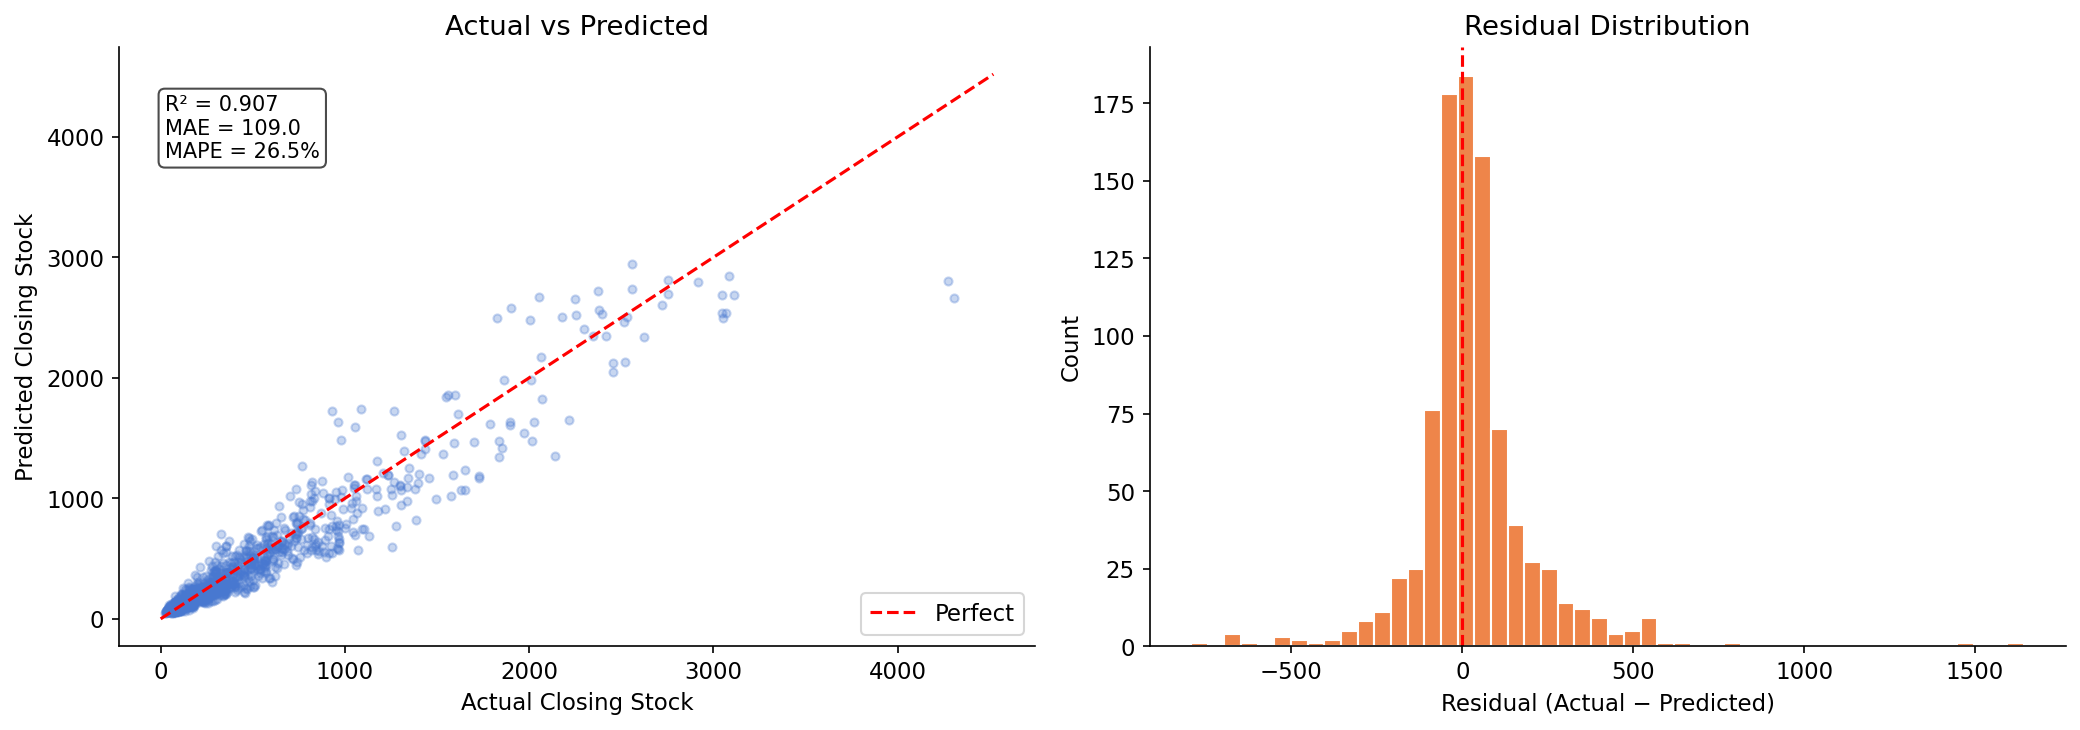

In [19]:
val_df = val_df.copy()
val_df['predicted'] = y_pred_val

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_val, y_pred_val, alpha=0.3, s=15, color=PALETTE[0])
lim = max(y_val.max(), y_pred_val.max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect')
axes[0].set_xlabel('Actual Closing Stock'); axes[0].set_ylabel('Predicted Closing Stock')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()
axes[0].text(0.05, 0.92, f'R² = {r2:.3f}\nMAE = {mae:.1f}\nMAPE = {mape:.1f}%',
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Residuals
residuals = y_val.values - y_pred_val
axes[1].hist(residuals, bins=50, color=PALETTE[1], edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual − Predicted)'); axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/08_actual_vs_predicted.png', bbox_inches='tight')
plt.show()


### Prediction vs Actual by Combination

Time series overlays for four representative facility-drug combinations show whether the model tracks the seasonal and logistical dynamics of individual series rather than simply regressing to the district mean. Good coverage of both trend and level changes in these plots gives confidence that the global model generalises to specific combinations.

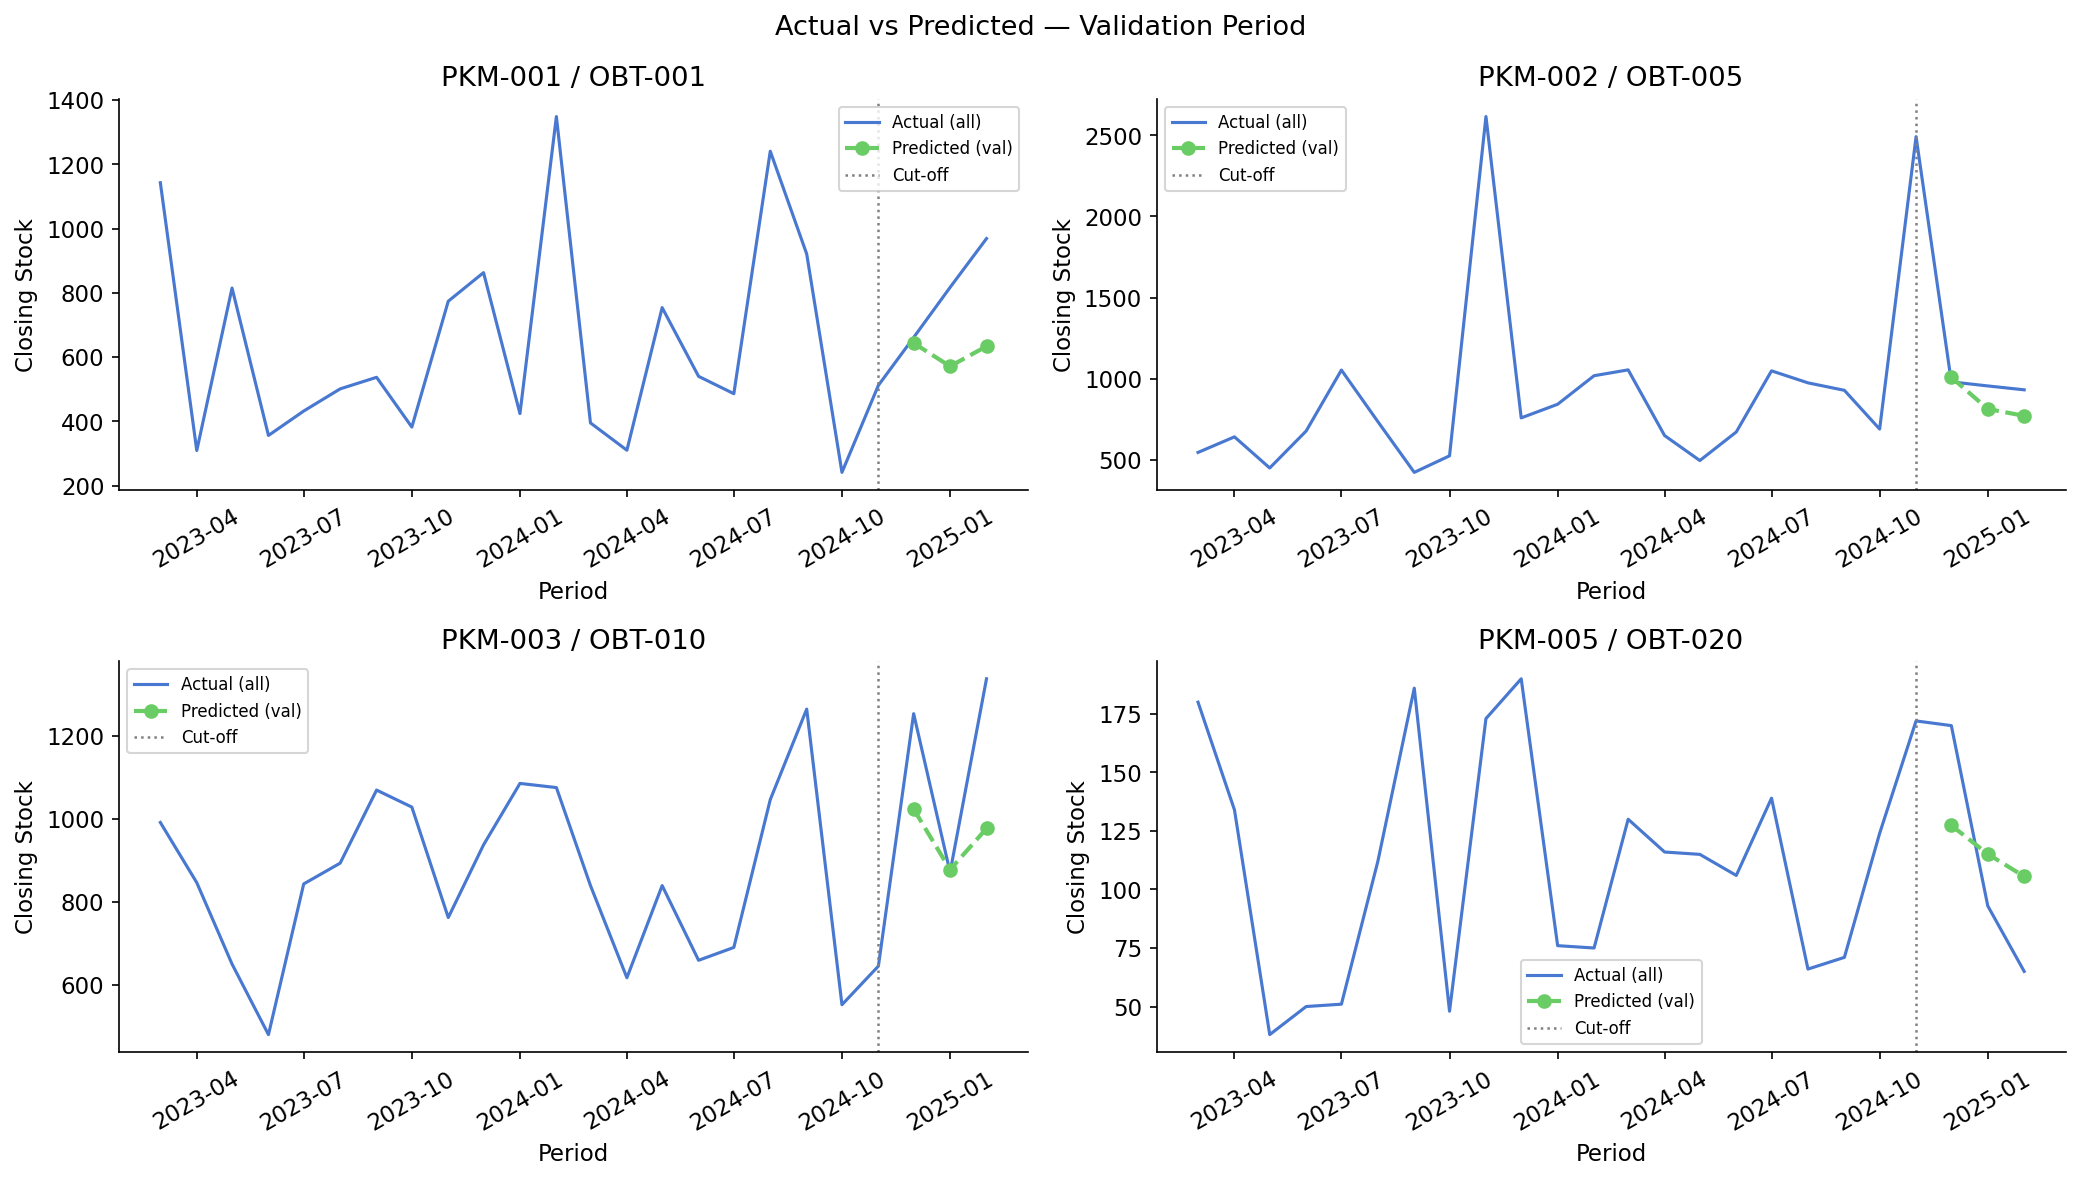

In [20]:
samples = [('PKM-001','OBT-001'), ('PKM-002','OBT-005'),
           ('PKM-003','OBT-010'), ('PKM-005','OBT-020')]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (fid, did) in zip(axes.flatten(), samples):
    hist = df[(df['facility_id']==fid) & (df['drug_id']==did)].sort_values('period')
    pred = val_df[(val_df['facility_id']==fid) & (val_df['drug_id']==did)].sort_values('period')

    ax.plot(hist['period'], hist['closing_stock'], color=PALETTE[0],
            linewidth=1.5, label='Actual (all)')
    if len(pred):
        ax.plot(pred['period'], pred['predicted'], 'o--', color=PALETTE[2],
                linewidth=2, markersize=6, label='Predicted (val)')
    ax.axvline(CUTOFF, color='gray', linestyle=':', linewidth=1.2, label='Cut-off')
    ax.set_title(f'{fid} / {did}')
    ax.set_xlabel('Period'); ax.set_ylabel('Closing Stock')
    ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=30)

plt.suptitle('Actual vs Predicted — Validation Period', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/09_val_predictions_sample.png', bbox_inches='tight')
plt.show()


### Feature Importance

Gain-based feature importance scores reveal which signals the model relies on most. The lag-one stock value and the rolling means are expected to dominate for stable combinations, while calendar and interaction features should contribute more for volatile or seasonal series.

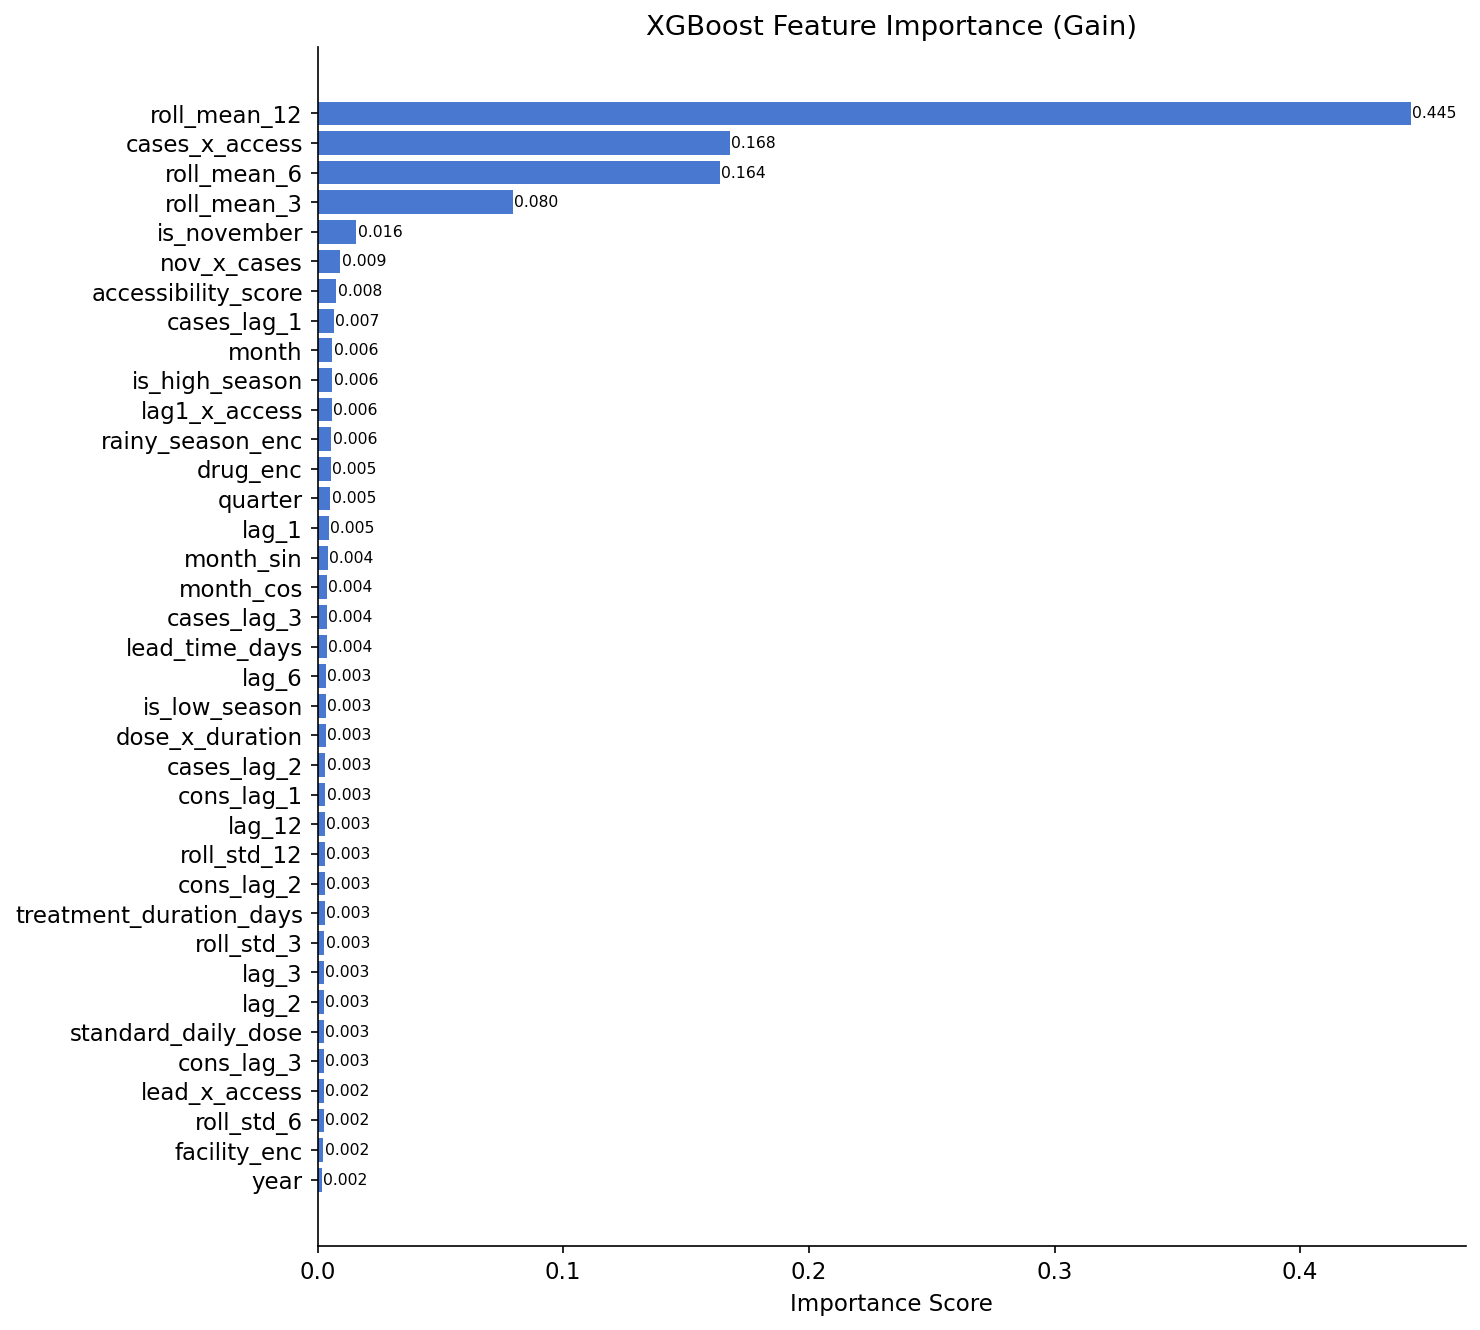

In [21]:
importance = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(importance.index, importance.values, color=PALETTE[0])
ax.set_title('XGBoost Feature Importance (Gain)')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, importance.values):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7.5)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/10_feature_importance.png', bbox_inches='tight')
plt.show()


### Metrics per Facility

Facility-level MAE and MAPE breakdowns identify whether the aggregate performance is driven by a small number of hard-to-forecast facilities or distributed evenly. Remote facilities with disrupted access tend to have higher error rates because their stock trajectories are more volatile.

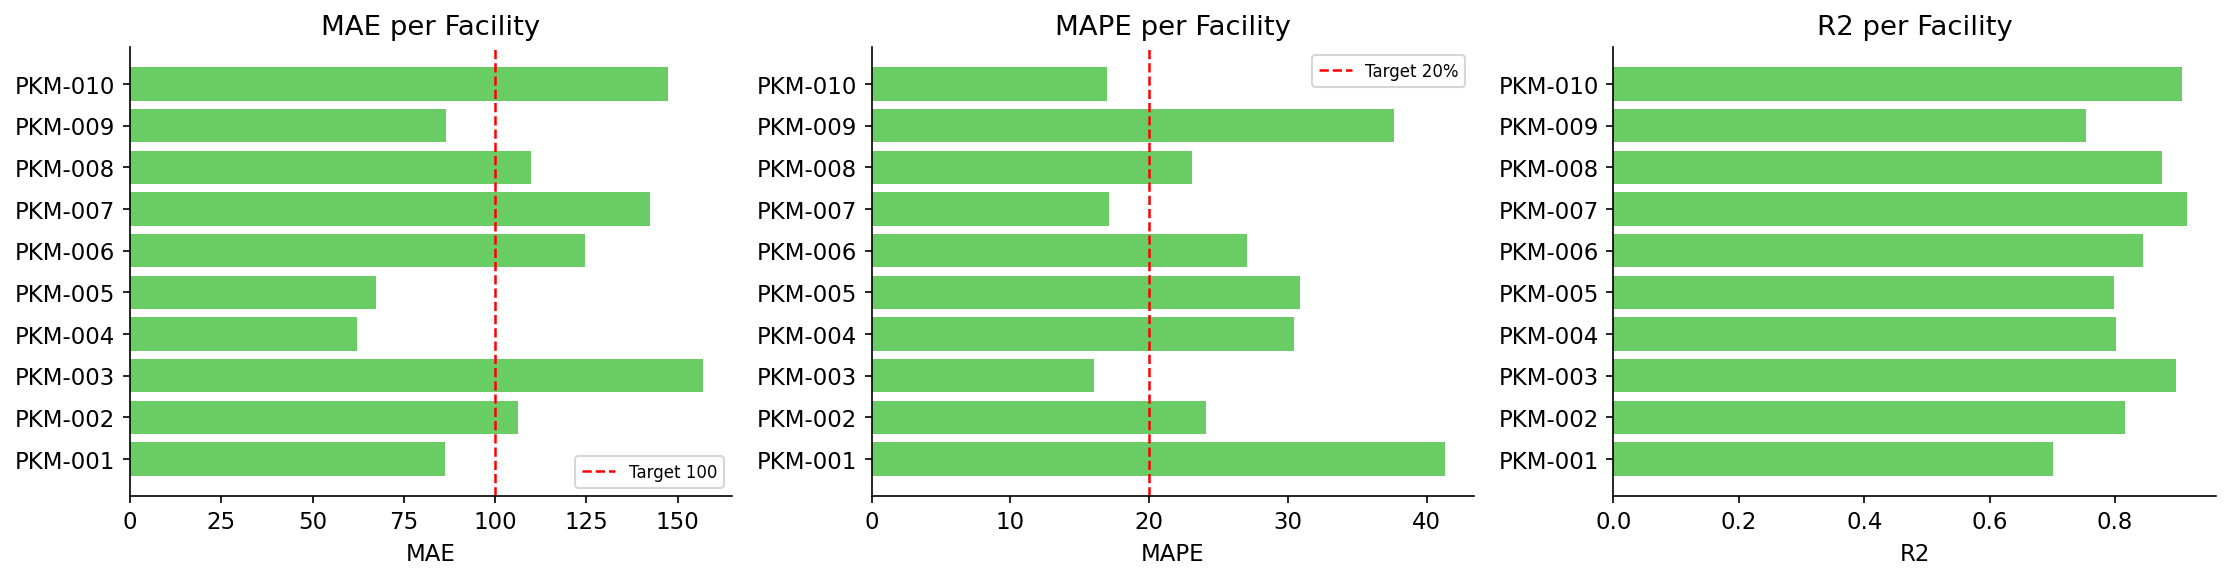

facility_id        MAE       RMSE      MAPE       R2
    PKM-001  86.393135 139.552074 41.337612 0.701008
    PKM-002 106.274086 175.852533 24.075871 0.815578
    PKM-003 157.006622 262.296290 16.020209 0.896602
    PKM-004  62.240765  92.251683 30.410202 0.801880
    PKM-005  67.362991  99.541066 30.880545 0.797689
    PKM-006 124.586243 180.117052 27.088577 0.845059
    PKM-007 142.277069 203.831684 17.129753 0.914465
    PKM-008 109.865562 163.229696 23.060826 0.874691
    PKM-009  86.452377 126.831169 37.633982 0.752925
    PKM-010 147.208252 251.423735 16.975014 0.906982


In [22]:
facility_metrics = []
for fid in sorted(val_df['facility_id'].unique()):
    sub = val_df[val_df['facility_id'] == fid]
    if len(sub) == 0: continue
    mape_f = np.mean(np.abs((sub[TARGET_COL].values - sub['predicted'].values) /
                            (sub[TARGET_COL].values + 1e-9))) * 100
    facility_metrics.append({
        'facility_id' : fid,
        'MAE'  : mean_absolute_error(sub[TARGET_COL], sub['predicted']),
        'RMSE' : np.sqrt(mean_squared_error(sub[TARGET_COL], sub['predicted'])),
        'MAPE' : mape_f,
        'R2'   : r2_score(sub[TARGET_COL], sub['predicted']),
    })
fm = pd.DataFrame(facility_metrics)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['MAE','MAPE','R2']):
    ax.barh(fm['facility_id'], fm[metric], color=PALETTE[2])
    ax.set_title(f'{metric} per Facility')
    ax.set_xlabel(metric)
    if metric == 'MAPE':
        ax.axvline(20, color='red', linestyle='--', linewidth=1.2, label='Target 20%')
        ax.legend(fontsize=8)
    if metric == 'MAE':
        ax.axvline(100, color='red', linestyle='--', linewidth=1.2, label='Target 100')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/11_metrics_per_facility.png', bbox_inches='tight')
plt.show()
print(fm.to_string(index=False))


### Error Distribution by Drug

APE distributions per drug reveal whether certain drugs are systematically harder to forecast, for example cold chain drugs with near-zero stock at many facilities or drugs whose demand is tightly coupled to the November incidence spike.

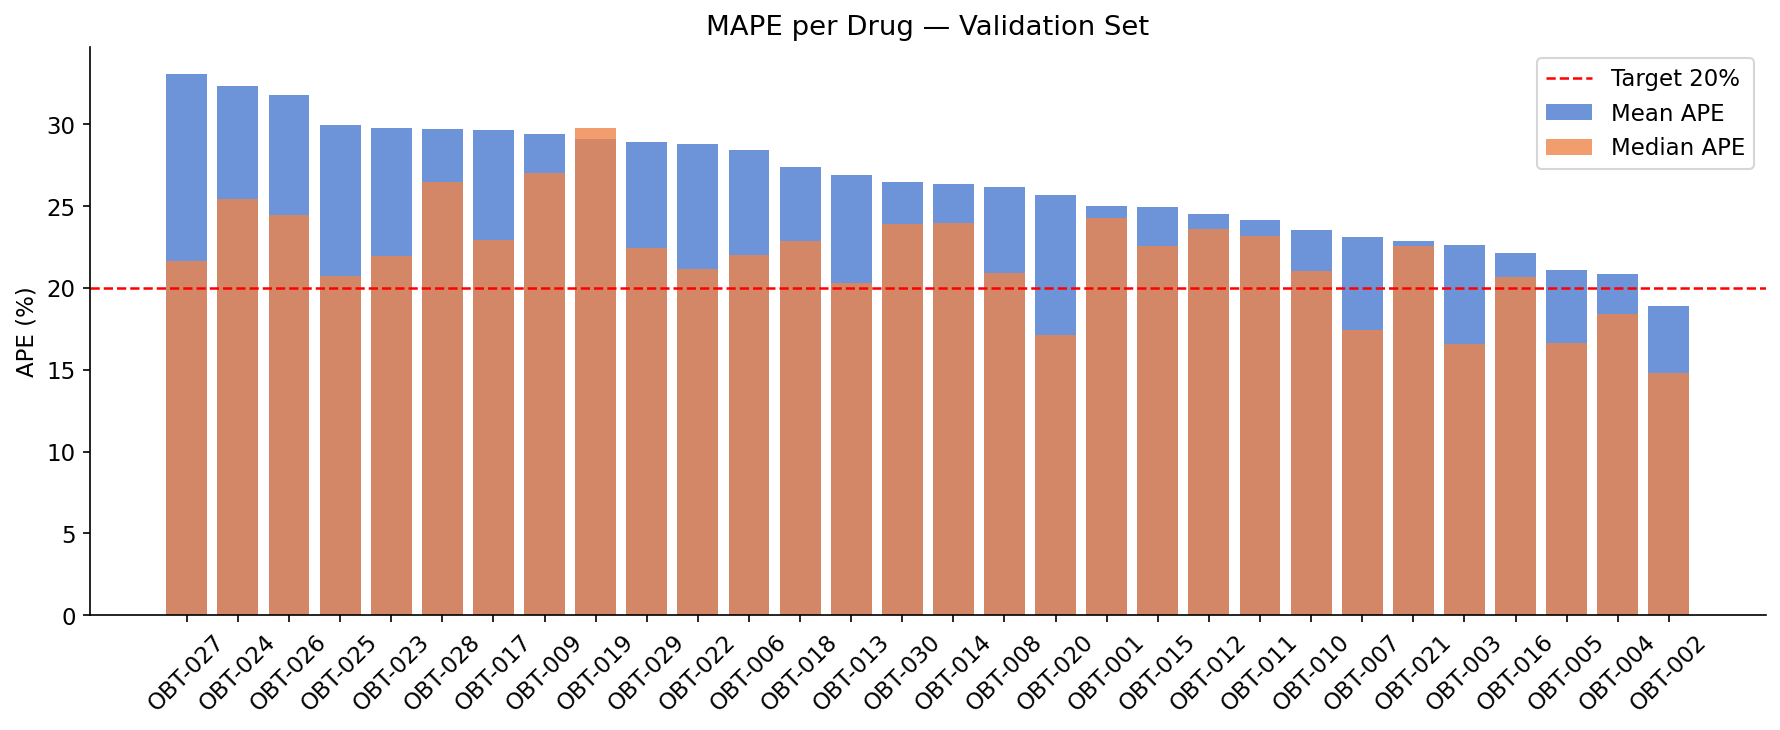

              mean     median
drug_id                      
OBT-027  33.075059  21.674060
OBT-024  32.360236  25.415968
OBT-026  31.814975  24.449206
OBT-025  29.938922  20.723536
OBT-023  29.770668  21.979654
OBT-028  29.742206  26.488577
OBT-017  29.644973  22.903345
OBT-009  29.390116  27.050664
OBT-019  29.085061  29.789835
OBT-029  28.946370  22.449463
OBT-022  28.784180  21.145182
OBT-006  28.456580  22.005110
OBT-018  27.402321  22.854961
OBT-013  26.918964  20.314668
OBT-030  26.468177  23.899292
OBT-014  26.363171  23.991975
OBT-008  26.162304  20.943631
OBT-020  25.671978  17.119686
OBT-001  25.027333  24.245932
OBT-015  24.937591  22.542795
OBT-012  24.510464  23.600392
OBT-011  24.140423  23.188884
OBT-010  23.543312  21.015156
OBT-007  23.111753  17.437706
OBT-021  22.889977  22.575380
OBT-003  22.654275  16.557353
OBT-016  22.166662  20.641292
OBT-005  21.105771  16.630597
OBT-004  20.835775  18.384581
OBT-002  18.918177  14.799358


In [23]:
# APE per row
val_df['ape'] = np.abs((val_df[TARGET_COL] - val_df['predicted']) /
                       (val_df[TARGET_COL] + 1e-9)) * 100

drug_ape = val_df.groupby('drug_id')['ape'].agg(['mean','median']).sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(drug_ape))
ax.bar(x, drug_ape['mean'],   label='Mean APE',   color=PALETTE[0], alpha=0.8)
ax.bar(x, drug_ape['median'], label='Median APE', color=PALETTE[1], alpha=0.8)
ax.axhline(20, color='red', linestyle='--', linewidth=1.2, label='Target 20%')
ax.set_xticks(x); ax.set_xticklabels(drug_ape.index, rotation=45)
ax.set_title('MAPE per Drug — Validation Set')
ax.set_ylabel('APE (%)'); ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/12_mape_per_drug.png', bbox_inches='tight')
plt.show()
print(drug_ape.to_string())


## Forecast One Month Ahead

For each facility-drug combination the most recent row of the panel provides the lag and rolling features for the forecast period. Static exogenous attributes are retrieved from the lookup table. Calendar features are set to the target month. The model outputs a log1p-scale prediction that is inverted with expm1 and clipped to zero to produce the final closing stock forecast.

In [24]:
FORECAST_PERIOD = df['period'].max() + pd.DateOffset(months=1)
print(f'Forecasting for: {FORECAST_PERIOD.date()}')

def get_lag_val(df_full, fid, did, col, lag):
    sub = df_full[(df_full['facility_id']==fid) & (df_full['drug_id']==did)].sort_values('period')
    vals = sub[col].values
    return vals[-lag] if len(vals) >= lag else (vals[-1] if len(vals) else np.nan)

def get_rolling(df_full, fid, did, window, agg='mean'):
    sub = df_full[(df_full['facility_id']==fid) & (df_full['drug_id']==did)].sort_values('period')
    vals = sub['closing_stock'].values
    if agg == 'mean':
        return np.mean(vals[-window:]) if len(vals) >= 1 else np.nan
    return np.std(vals[-window:]) if len(vals) >= 2 else 0.0

forecast_rows = []
last_rows = df.groupby(['facility_id','drug_id']).tail(1).reset_index(drop=True)

for _, row in last_rows.iterrows():
    fid, did = row['facility_id'], row['drug_id']
    exog = static_lookup[(static_lookup['facility_id']==fid) &
                         (static_lookup['drug_id']==did)].iloc[0]

    lag1_val = get_lag_val(df, fid, did, 'closing_stock', 1)
    feat = {
        # Stock lags
        'lag_1'  : lag1_val,
        'lag_2'  : get_lag_val(df, fid, did, 'closing_stock', 2),
        'lag_3'  : get_lag_val(df, fid, did, 'closing_stock', 3),
        'lag_6'  : get_lag_val(df, fid, did, 'closing_stock', 6),
        'lag_12' : get_lag_val(df, fid, did, 'closing_stock', 12),
        # Cases lags
        'cases_lag_1': get_lag_val(df, fid, did, 'estimated_total_cases', 1),
        'cases_lag_2': get_lag_val(df, fid, did, 'estimated_total_cases', 2),
        'cases_lag_3': get_lag_val(df, fid, did, 'estimated_total_cases', 3),
        # Consumption lags
        'cons_lag_1': get_lag_val(df, fid, did, 'estimated_consumption', 1),
        'cons_lag_2': get_lag_val(df, fid, did, 'estimated_consumption', 2),
        'cons_lag_3': get_lag_val(df, fid, did, 'estimated_consumption', 3),
        # Rolling
        'roll_mean_3'  : get_rolling(df, fid, did, 3),
        'roll_mean_6'  : get_rolling(df, fid, did, 6),
        'roll_mean_12' : get_rolling(df, fid, did, 12),
        'roll_std_3'   : get_rolling(df, fid, did, 3, 'std'),
        'roll_std_6'   : get_rolling(df, fid, did, 6, 'std'),
        'roll_std_12'  : get_rolling(df, fid, did, 12, 'std'),
        # Static exog
        'facility_enc'           : exog['facility_enc'],
        'drug_enc'               : exog['drug_enc'],
        'lead_time_days'         : exog['lead_time_days'],
        'rainy_season_enc'       : exog['rainy_season_enc'],
        'accessibility_score'    : exog['accessibility_score'],
        'standard_daily_dose'    : exog['standard_daily_dose'],
        'treatment_duration_days': exog['treatment_duration_days'],
        # Calendar
        'month'          : FORECAST_PERIOD.month,
        'month_sin'      : np.sin(2 * np.pi * FORECAST_PERIOD.month / 12),
        'month_cos'      : np.cos(2 * np.pi * FORECAST_PERIOD.month / 12),
        'year'           : FORECAST_PERIOD.year,
        'quarter'        : FORECAST_PERIOD.quarter,
        'is_november'    : int(FORECAST_PERIOD.month == 11),
        'is_high_season' : int(FORECAST_PERIOD.month in [10,11,12]),
        'is_low_season'  : int(FORECAST_PERIOD.month == 4),
        # Interactions
        'cases_x_access' : get_lag_val(df, fid, did, 'estimated_total_cases', 1) * exog['accessibility_score'],
        'lead_x_access'  : exog['lead_time_days'] * exog['accessibility_score'],
        'nov_x_cases'    : int(FORECAST_PERIOD.month == 11) * get_lag_val(df, fid, did, 'estimated_total_cases', 1),
        'dose_x_duration': exog['standard_daily_dose'] * exog['treatment_duration_days'],
        'lag1_x_access'  : lag1_val * exog['accessibility_score'],
    }
    feat['facility_id'] = fid
    feat['drug_id']     = did
    forecast_rows.append(feat)

forecast_df = pd.DataFrame(forecast_rows)
X_forecast  = forecast_df[FEATURE_COLS]

pred_log = model.predict(X_forecast)
forecast_df['predicted_closing_stock'] = np.clip(np.expm1(pred_log), 0, None).round(0).astype(int)
forecast_df['forecast_period'] = FORECAST_PERIOD.date()

result_cols = ['facility_id','drug_id','forecast_period','predicted_closing_stock']
forecast_df[result_cols].to_csv(f'{MODEL_DIR}/forecast_march_2025.csv', index=False)
print(f'Forecast saved — {len(forecast_df)} combinations.')
forecast_df[result_cols].head(10)


Forecasting for: 2025-03-01
Forecast saved — 300 combinations.


,facility_id,drug_id,forecast_period,predicted_closing_stock
0,PKM-001,OBT-001,2025-03-01,663
1,PKM-001,OBT-002,2025-03-01,543
2,PKM-001,OBT-003,2025-03-01,592
3,PKM-001,OBT-004,2025-03-01,488
4,PKM-001,OBT-005,2025-03-01,394
5,PKM-001,OBT-006,2025-03-01,289
6,PKM-001,OBT-007,2025-03-01,299
7,PKM-001,OBT-008,2025-03-01,270
8,PKM-001,OBT-009,2025-03-01,243
9,PKM-001,OBT-010,2025-03-01,249


### Forecast Distribution and Per-Facility Summary

The distribution of predicted closing stocks across all combinations and the per-facility averages give a district-wide view of the procurement signal generated by Layer 1. Facilities with systematically low forecasts flag potential stockout risk for Layer 2.

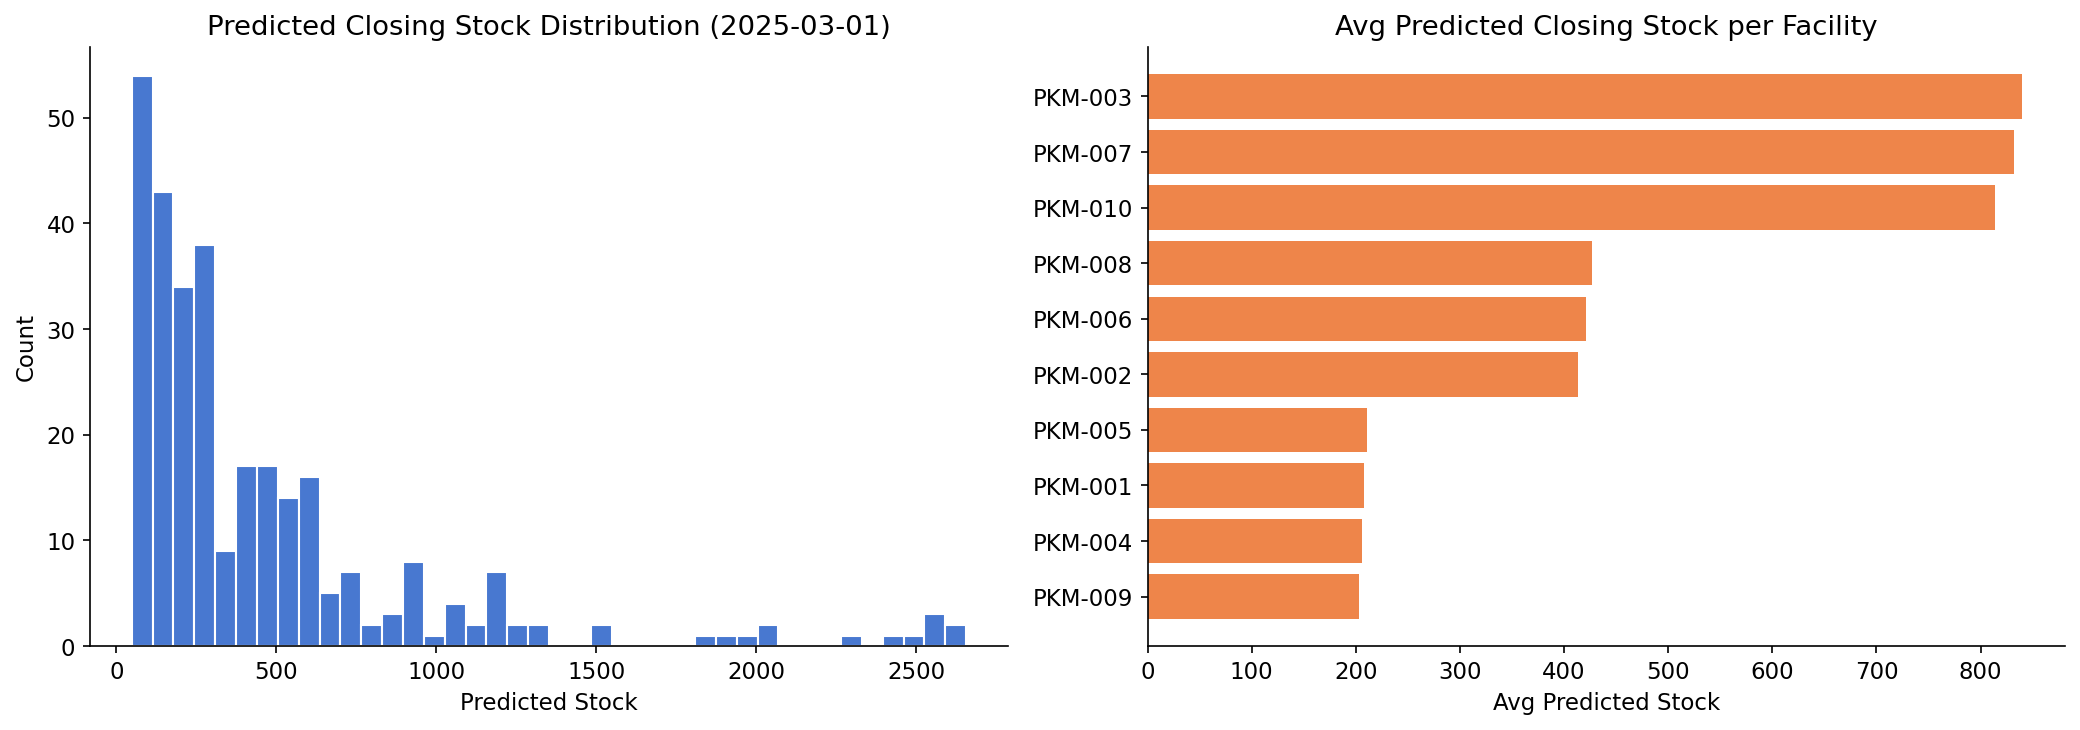

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(forecast_df['predicted_closing_stock'], bins=40, color=PALETTE[0], edgecolor='white')
axes[0].set_title(f'Predicted Closing Stock Distribution ({FORECAST_PERIOD.date()})')
axes[0].set_xlabel('Predicted Stock'); axes[0].set_ylabel('Count')

fac_pred = forecast_df.groupby('facility_id')['predicted_closing_stock'].mean().sort_values()
axes[1].barh(fac_pred.index, fac_pred.values, color=PALETTE[1])
axes[1].set_title('Avg Predicted Closing Stock per Facility')
axes[1].set_xlabel('Avg Predicted Stock')

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/13_forecast_distribution.png', bbox_inches='tight')
plt.show()


### Historical and Forecast Sample Combinations

Overlaying the historical series with the one-month-ahead point forecast for four sample combinations provides a visual sanity check that the predictions are consistent with the recent trajectory of each series.

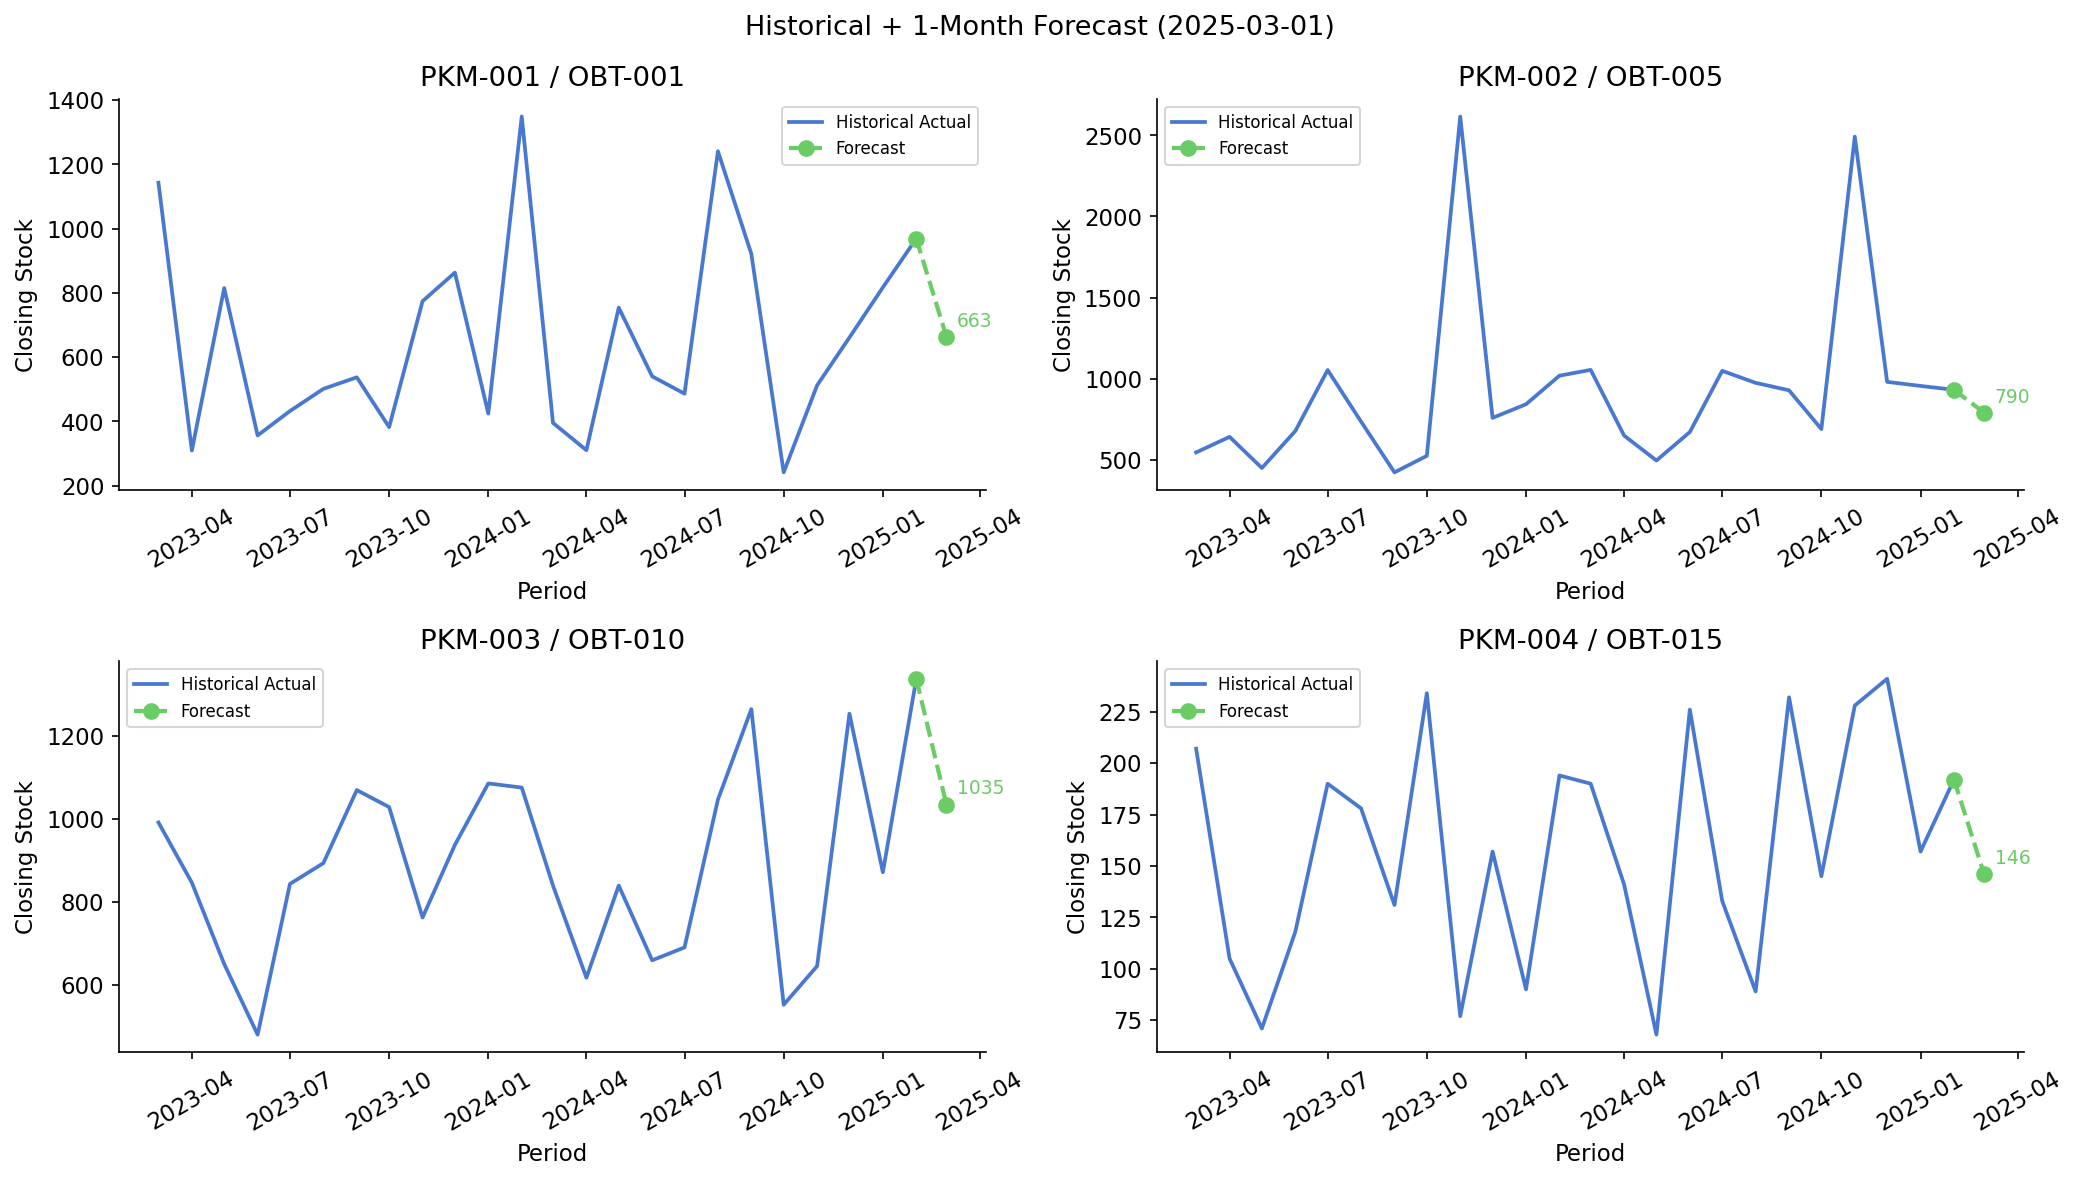

In [26]:
samples = [('PKM-001','OBT-001'), ('PKM-002','OBT-005'),
           ('PKM-003','OBT-010'), ('PKM-004','OBT-015')]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (fid, did) in zip(axes.flatten(), samples):
    hist = df[(df['facility_id']==fid) & (df['drug_id']==did)].sort_values('period')
    pred_val = forecast_df[
        (forecast_df['facility_id']==fid) & (forecast_df['drug_id']==did)
    ]['predicted_closing_stock'].values[0]

    ax.plot(hist['period'], hist['closing_stock'], color=PALETTE[0],
            linewidth=1.8, label='Historical Actual')
    ax.plot([hist['period'].iloc[-1], FORECAST_PERIOD],
            [hist['closing_stock'].iloc[-1], pred_val],
            'o--', color=PALETTE[2], linewidth=2, markersize=7, label='Forecast')
    ax.annotate(f'{pred_val}', xy=(FORECAST_PERIOD, pred_val),
                xytext=(5, 5), textcoords='offset points', fontsize=9, color=PALETTE[2])
    ax.set_title(f'{fid} / {did}')
    ax.set_xlabel('Period'); ax.set_ylabel('Closing Stock')
    ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=30)

plt.suptitle(f'Historical + 1-Month Forecast ({FORECAST_PERIOD.date()})', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/14_forecast_sample_combos.png', bbox_inches='tight')
plt.show()


### Forecast Heatmap

A facility-by-drug heatmap of predicted closing stocks surfaces which drug-facility combinations are most at risk of running low. The first fifteen drugs by identifier are shown to keep the figure readable.

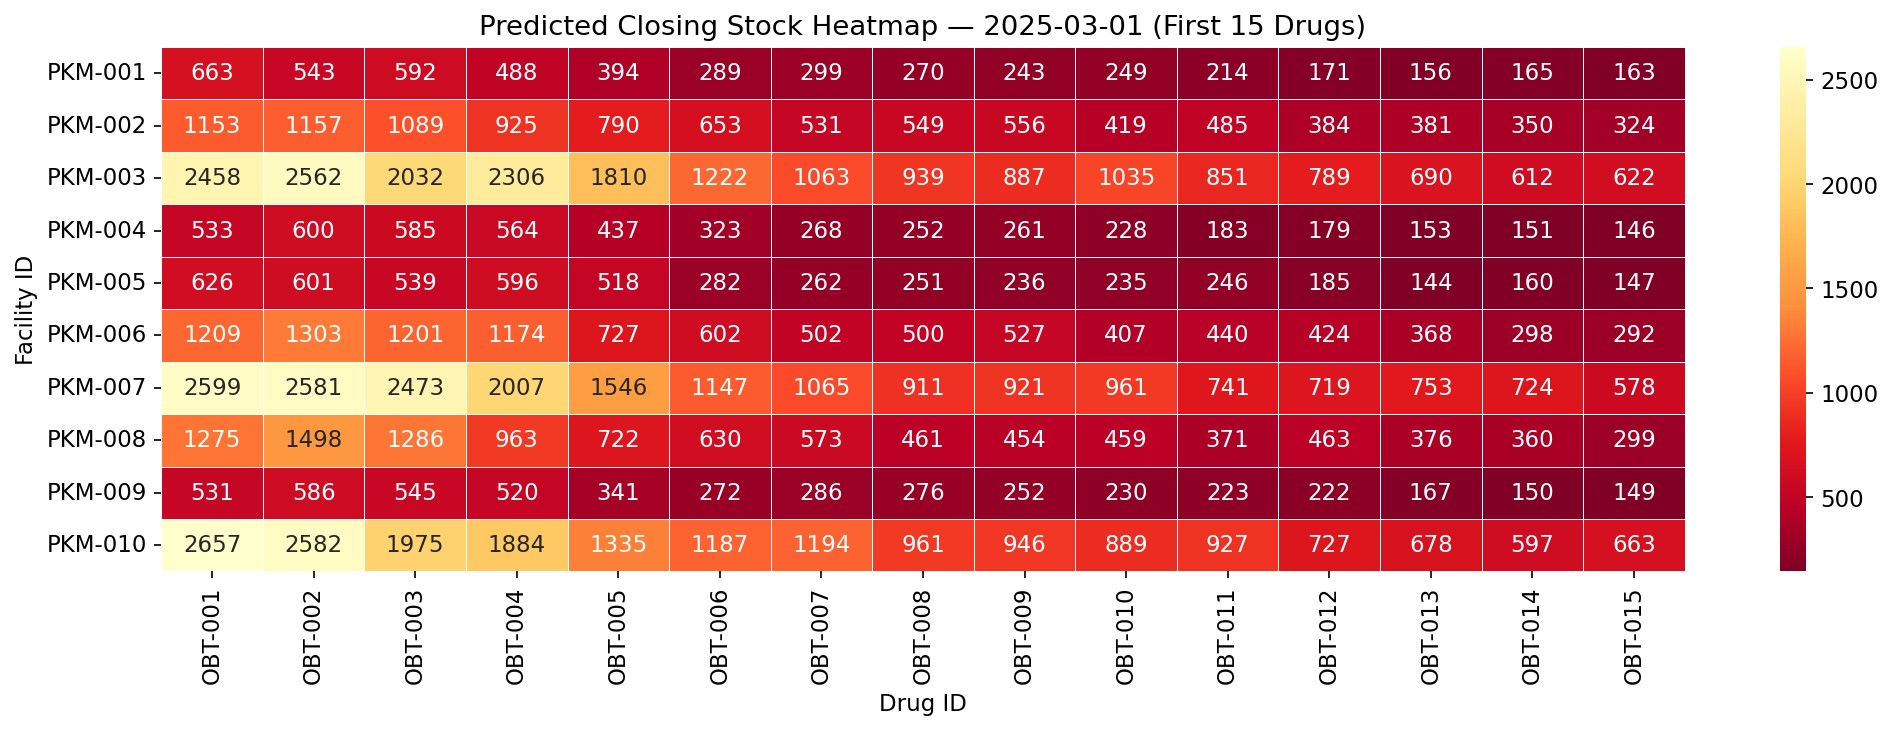

In [27]:
top_drugs = sorted(forecast_df['drug_id'].unique())[:15]
hmap_data = (
    forecast_df[forecast_df['drug_id'].isin(top_drugs)]
    .pivot(index='facility_id', columns='drug_id', values='predicted_closing_stock')
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(hmap_data, annot=True, fmt='d', cmap='YlOrRd_r', linewidths=0.3, ax=ax)
ax.set_title(f'Predicted Closing Stock Heatmap — {FORECAST_PERIOD.date()} (First 15 Drugs)')
ax.set_xlabel('Drug ID'); ax.set_ylabel('Facility ID')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/15_forecast_heatmap.png', bbox_inches='tight')
plt.show()


## Summary and Saved Artifacts

The trained XGBoost model, the label encoders, the static exogenous lookup table, the feature column list, and the one-month forecast CSV are written to the model directory. The inference guide at the end of this cell documents the exact sequence of steps required to reproduce a prediction from these artifacts, which is the contract consumed by the FastAPI serving layer.

In [28]:
print('=== Final Validation Metrics ===')
print(f'  MAE   : {mae:.2f}   (target < 100)')
print(f'  MAPE  : {mape:.2f}%  (target < 20%)')
print(f'  SMAPE : {smape:.2f}%')
print(f'  RMSE  : {rmse:.2f}')
print(f'  R²    : {r2:.4f}')
print()

print('=== Saved Files ===')
print(f'[MODEL DIR] {MODEL_DIR}/')
for f in sorted(os.listdir(MODEL_DIR)):
    sz = os.path.getsize(f'{MODEL_DIR}/{f}')
    print(f'  {f:<45} {sz:>10,} bytes')

print()
print(f'[FIGURE DIR] {FIGURE_DIR}/')
for f in sorted(os.listdir(FIGURE_DIR)):
    sz = os.path.getsize(f'{FIGURE_DIR}/{f}')
    print(f'  {f:<55} {sz:>10,} bytes')

print()
print('=== Inference Guide ===')
print('1. Load: xgboost_drug_forecast_v3.json + static_exog_lookup.csv + feature_cols.pkl')
print('2. For each facility-drug combo: build lag/rolling from closing_stock history')
print('3. Retrieve static exog from lookup table')
print('4. Set calendar features for forecast month')
print('5. model.predict(X) → np.expm1(pred) → closing_stock forecast')


=== Final Validation Metrics ===
  MAE   : 108.97   (target < 100)
  MAPE  : 26.46%  (target < 20%)
  SMAPE : 25.50%
  RMSE  : 178.20
  R²    : 0.9071

=== Saved Files ===
[MODEL DIR] /content/drive/MyDrive/ai-asean/model_v3/
  feature_cols.pkl                                     530 bytes
  forecast_march_2025.csv                            9,352 bytes
  le_drug.pkl                                          773 bytes
  le_facility.pkl                                      573 bytes
  le_rainy.pkl                                         505 bytes
  static_exog_lookup.csv                            10,238 bytes
  validation_metrics.json                              149 bytes
  xgboost_drug_forecast_v3.json                  1,877,594 bytes

[FIGURE DIR] /content/drive/MyDrive/ai-asean/figures_v3/
  01_closing_stock_distribution.png                           78,502 bytes
  02_monthly_trend.png                                       100,859 bytes
  03_trend_by_facility.png                    